# Track identification: relation-aware r-GCN/HGT with invariant RAO and variable radar mode

This notebook is derived from `observation_series_and_intel_rgcn_classification_advanced_network_llm.ipynb`. It changes the learning unit from an individual observation to a hierarchical track/observation representation:

* the r-GCN/HGT encoder still produces contextual observation embeddings;
* a gated, mask-aware pool produces exactly one embedding per `series_id`;
* one joint, KG-valid aircraft/radar/operator (**RAO**) head classifies each track;
* a radar-mode head classifies each observation, conditioned on its local embedding and the soft track-level RAO distribution; and
* categorical and Dirichlet/Subjective-Logic losses are balanced by track, so long series do not dominate.

The output schema, evaluation dashboard, and local-Ollama explanation likewise contain one invariant RAO assessment per track and an ordered, changeable radar-mode sequence. Ground truth remains outside inference features, and train/test/validation allocation remains grouped by complete tracks.


In [1]:
from __future__ import annotations

import json, math, os, random, sys, time
import urllib.error, urllib.parse, urllib.request
from array import array
from collections import Counter, defaultdict
from concurrent.futures import ProcessPoolExecutor
from dataclasses import dataclass
from datetime import UTC, datetime
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.utils.checkpoint
from torch import nn
import torch.nn.functional as F
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ROOT = Path("..").resolve() if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from rgcn_fusion import attribute_assessments, decode_kg_constrained
from esm_observation_series_generator import load_observation_series_json
from rgcn_fusion.intelligence_reports import (
    report_claim_score,
    report_recency_score,
)
from kg_generator import generate_graph
from rgcn_fusion.graph_optimisation import (
    build_track_graph_batches_by_split,
    densify_feature_rows,
    partition_edges_by_relation,
    segment_softmax,
    standardize_feature_matrix_in_place,
)
from rgcn_fusion.parallel_graph_construction import (
    build_series_fragment,
    build_series_fragment_in_worker,
    initialise_scoring_worker,
    score_series_in_worker,
    score_series_observations,
)
DATA_PATH = ROOT / "generated" / "demo_esm_observation_series_with_sightings_and_patterns.json"
ARTIFACT_DIR = ROOT / "artifacts" / "Track_identification"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
print(DATA_PATH)
print(ARTIFACT_DIR)
print(DEVICE)



C:\Users\theon\r-GCN_fusion\generated\demo_esm_observation_series_with_sightings_and_patterns.json
C:\Users\theon\r-GCN_fusion\artifacts\Track_identification
cuda


## Load series and create a label-free inference view

Ground-truth fields are retained in a separate target table, but are recursively stripped from the feature payload before graph construction. This prevents leakage from `ground_truth_label`, `ground_truth_track_label`, and `ground_truth_mode_sequence` into node features or edges.



In [2]:
LEAKAGE_KEYS = {"ground_truth_label", "ground_truth_track_label", "ground_truth_mode_sequence", "synthetic_truth_value"}
TARGETS = ["aircraft_variant", "radar_mode", "radar_type", "operator_country"]

def strip_ground_truth(obj: Any) -> Any:
    if isinstance(obj, dict):
        return {k: strip_ground_truth(v) for k, v in obj.items() if k not in LEAKAGE_KEYS}
    if isinstance(obj, list):
        return [strip_ground_truth(v) for v in obj]
    return obj

raw = load_observation_series_json(DATA_PATH)
series_records = raw["observation_series"]
inference_records = strip_ground_truth(series_records)

# Evaluation labels remain outside the inference graph. Track-level truth is retained
# separately so the final explanation output can show the correct identification.
track_targets_by_series_id = {
    series["series_id"]: dict(series["ground_truth_track_label"])
    for series in series_records
}
if len(track_targets_by_series_id) != len(series_records):
    raise ValueError("series_id values must be unique to report correct track identifications")

# Observation targets are extracted only from the original payload and never merged back into features.
target_rows = []
for s in series_records:
    for obs in s["observations"]:
        gt = obs["ground_truth_label"]
        target_rows.append({
            "observation_id": obs["observation_id"],
            "series_id": obs["series_id"],
            "sequence_index": obs["sequence_index"],
            "aircraft_variant": gt.get("aircraft_variant"),
            "radar_mode": gt.get("mode") or gt.get("radar_mode"),
            "radar_type": gt.get("radar") or gt.get("radar_type"),
            "operator_country": gt.get("operator") or gt.get("operator_country"),
        })

serialized_features = json.dumps(inference_records)
assert "ground_truth" not in serialized_features, "Ground-truth fields leaked into inference view"
report_count = sum(len(series.get("intelligence_reports") or []) for series in series_records)
print(f"series={len(series_records):,}, observations={len(target_rows):,}, intelligence_reports={report_count:,}")
print(target_rows[0])



series=1,250, observations=58,032, intelligence_reports=6,222
{'observation_id': 'esm_series_00001_obs_001', 'series_id': 'esm_series_00001', 'sequence_index': 0, 'aircraft_variant': 'F-16V Block 70/72', 'radar_mode': 'look_down_shoot_down', 'radar_type': 'AN/APG-83 SABR', 'operator_country': 'Slovakia'}


## Feature engineering with proximity-linked intelligence and KG entities

Observation features use measured ESM, kinematics, time, and location. Sighting reports are connected only where their reported time and coordinates are close to an observation; pattern-of-life reports use collection time and expected operating area. Structured aircraft, family, radar, and operator claims also connect directly to the corresponding existing KG entity nodes, allowing the NN to propagate report evidence through the domain graph.


In [3]:
INCLUDE_CANDIDATE_NODES = True
INCLUDE_INTEL_REPORT_NODES = True
USE_SEGMENT_EDGES = False
SEGMENT_FREQUENCY_SHIFT_GHZ = 0.75

MAX_KG_RETRIEVAL_CANDIDATES = 320
MAX_KG_CANDIDATES = 18
# Discard weak claim/candidate links and keep only claim -> candidate direction.
CLAIM_CANDIDATE_MIN_ABS_CONTRIBUTION = 0.15
COLLAPSE_RECIPROCAL_CLAIM_CANDIDATE_EDGES = True


In [4]:


GRAPH_CONSTRUCTION_WORKERS = max(1, int(os.getenv("GRAPH_CONSTRUCTION_WORKERS", os.cpu_count() or 14)))
# Amortise ProcessPool task dispatch/pickling while retaining enough chunks to keep
# workers busy when track sizes differ. Set to an integer to benchmark/override.
GRAPH_SCORING_CHUNKSIZE = os.getenv("GRAPH_SCORING_CHUNKSIZE", "auto").strip().lower()
# Dense feature normalisation is the tensor-heavy part of this cell and can use CUDA;
# scoring itself contains strings, dictionaries, date parsing, and variable-length DS
# evidence, which are poor GPU kernels unless redesigned as a packed tensor pipeline.
GRAPH_FEATURE_DEVICE = torch.device(os.getenv("GRAPH_FEATURE_DEVICE", str(DEVICE)))
GRAPH_INPUT_ARTIFACT = ARTIFACT_DIR / "graph_construction_outputs.pt"
GRAPH_FEATURE_MEMMAP = ARTIFACT_DIR / "graph_features.float16.memmap"
GRAPH_FEATURE_CHUNK_ROWS = max(1, int(os.getenv("GRAPH_FEATURE_CHUNK_ROWS", "262144")))
X_NP_DTYPE, TORCH_DATA_DTYPE = np.float16, torch.float16

kg = generate_graph()
kg_nodes = {node["id"]: node for node in kg["nodes"]}
radar_by_mode = {edge["target"]: edge["source"] for edge in kg["edges"] if edge["relation"] == "HAS_MODE"}
aircraft_by_radar: dict[str, list[str]] = defaultdict(list)
operators_by_aircraft: dict[str, list[str]] = defaultdict(list)
aircraft_family_by_aircraft: dict[str, str] = {}
for edge in kg["edges"]:
    if edge["relation"] == "USES_RADAR":
        aircraft_by_radar[edge["target"]].append(edge["source"])
    elif edge["relation"] == "OPERATES":
        operators_by_aircraft[edge["target"]].append(kg_nodes[edge["source"]]["properties"].get("name"))
    elif edge["relation"] == "VARIANT_OF":
        aircraft_family_by_aircraft[edge["source"]] = edge["target"]
kg_candidate_rows = [
    {
        "mode_id": mode_id, "mode_props": kg_nodes[mode_id]["properties"],
        "radar_id": radar_id, "radar_props": kg_nodes[radar_id]["properties"],
        "aircraft_id": aircraft_id,
        "aircraft_props": kg_nodes[aircraft_id]["properties"] if aircraft_id else None,
        "aircraft_uses_radar": aircraft_id is not None, "operator": operator,
    }
    for mode_id, radar_id in radar_by_mode.items()
    for aircraft_id in (aircraft_by_radar.get(radar_id) or [None])
    for operator in (operators_by_aircraft.get(aircraft_id, [None]) if aircraft_id else [None])
]

# A radar can legitimately have modes in the KG without any USES_RADAR edge from an
# aircraft.  The ``or [None]`` fallback above preserves such a radar-only hypothesis;
# it is the source of CandidateScore.aircraft_id == None (not a missing dictionary key).
radars_without_aircraft = sum(not aircraft_by_radar.get(radar_id) for radar_id in radar_by_mode.values())
print(f"Radar-only candidate fallback used for {radars_without_aircraft:,} radar mode(s)")

# Elementary DS worlds are complete, mutually exclusive KG-valid configurations.
# Aircraft family is projected from the joint frame rather than trained as an
# unrelated head, preserving its deterministic relationship to the variant.
kg_valid_worlds = []
seen_kg_worlds = set()
for row in kg_candidate_rows:
    if not row["aircraft_id"] or not row["operator"]:
        continue
    world = {
        "radar_mode": row["mode_props"].get("name"),
        "radar_type": row["radar_props"].get("name"),
        "aircraft_variant": row["aircraft_props"].get("variant"),
        "aircraft_family": row["aircraft_props"].get("family"),
        "operator_country": row["operator"],
    }
    key = tuple(world[name] for name in ("radar_mode", "radar_type", "aircraft_variant", "aircraft_family", "operator_country"))
    if None not in key and key not in seen_kg_worlds:
        seen_kg_worlds.add(key)
        kg_valid_worlds.append(world)
print(f"KG-valid joint frame: {len(kg_valid_worlds):,} elementary worlds")

# score_candidates repeats the same mode/aircraft calculation once per operator.
# Score one template per mode/radar/aircraft tuple, then expand its operator variants.
candidate_variants: dict[tuple[str, str | None, str | None], list[dict[str, Any]]] = defaultdict(list)
for row in kg_candidate_rows:
    candidate_variants[(row["mode_id"], row["radar_id"], row["aircraft_id"])].append(row)
candidate_templates = [{**rows[0], "operator": None} for rows in candidate_variants.values()]


def flatten_numeric(prefix: str, value: Any, out: dict[str, float]) -> None:
    if isinstance(value, dict):
        for k, v in value.items():
            flatten_numeric(f"{prefix}.{k}" if prefix else k, v, out)
    elif isinstance(value, (int, float)) and not isinstance(value, bool):
        out[prefix] = float(value)


def _numeric_value(value: Any) -> float | None:
    if isinstance(value, dict):
        value = value.get("value")
    return float(value) if isinstance(value, (int, float)) and not isinstance(value, bool) else None


def segment_indices(observations: list[dict[str, Any]]) -> list[int]:
    """Infer coarse transition markers from measured frequency only, never labels/candidates."""
    frequencies = [_numeric_value(obs.get("esm_radar_parameters", {}).get("measured_centre_frequency_ghz")) for obs in observations]
    segments, current = [], 0
    for index, frequency in enumerate(frequencies):
        if index and frequency is not None and frequencies[index - 1] is not None and abs(frequency - frequencies[index - 1]) > SEGMENT_FREQUENCY_SHIFT_GHZ:
            current += 1
        segments.append(current)
    return segments




feature_rows, node_meta = [], []
observation_node_indices: list[int] = []
observation_nodes_by_series: dict[str, list[int]] = defaultdict(list)
candidates_by_observation_node: dict[int, list[int]] = defaultdict(list)
reports_by_observation_node: dict[int, list[int]] = defaultdict(list)
claims_by_observation_node: dict[int, list[int]] = defaultdict(list)
claims_by_claim_type: dict[tuple[str, str], list[int]] = defaultdict(list)
# Encode contribution polarity in the sign of the one-based claim index. Together
# with the candidate index this is eight bytes per edge, with no per-edge dictionaries
# and no separate sign buffer.
claim_candidate_signed_claim_indices = array("i")
claim_candidate_node_indices = array("i")
claim_node_indices_by_series: dict[str, list[int]] = defaultdict(list)
kg_entity_node_indices: dict[str, int] = {}
report_kg_edges: list[tuple[int, int]] = []
# Recall evaluation retains only (first-correct-rank, candidate-count) integer pairs;
# complete scored candidate payloads continue to be released as each fragment is merged.
candidate_recall_rank_counts: list[tuple[int, int]] = []


Radar-only candidate fallback used for 10 radar mode(s)
KG-valid joint frame: 920 elementary worlds


In [17]:

# Candidate and intelligence scoring is CPU-bound and independent by track. Workers
# return index-free fragments; this process assigns all global graph indices below.
RECALL_FIELDS = ("aircraft_variant", "radar_mode", "radar_type", "operator_country")
recall_target_by_observation_id = {
    row["observation_id"]: tuple(row[field] for field in RECALL_FIELDS)
    for row in target_rows
}
recall_label_by_candidate = {
    (row["mode_id"], row["radar_id"], row["aircraft_id"], row["operator"]): (
        (row["aircraft_props"] or {}).get("variant"),
        row["mode_props"].get("name"),
        row["radar_props"].get("name"),
        row["operator"],
    )
    for row in kg_candidate_rows
}
scoring_context = {
    "candidate_templates": candidate_templates,
    "candidate_variants": dict(candidate_variants),
    "aircraft_family_by_aircraft": aircraft_family_by_aircraft,
    "max_kg_retrieval_candidates": MAX_KG_RETRIEVAL_CANDIDATES,
    "max_kg_candidates": MAX_KG_CANDIDATES,
    "claim_candidate_min_abs_contribution": CLAIM_CANDIDATE_MIN_ABS_CONTRIBUTION,
    "include_candidate_nodes": INCLUDE_CANDIDATE_NODES,
    "include_intel_report_nodes": INCLUDE_INTEL_REPORT_NODES,
    "segment_frequency_shift_ghz": SEGMENT_FREQUENCY_SHIFT_GHZ,
    # Evaluation-only lookups let workers emit compact rank/count pairs while the
    # fully enriched candidate lists are already resident for graph construction.
    "recall_target_by_observation_id": recall_target_by_observation_id,
    "recall_label_by_candidate": recall_label_by_candidate,
}
task_count = len(inference_records)
worker_count = min(GRAPH_CONSTRUCTION_WORKERS, max(task_count, 1))
if GRAPH_SCORING_CHUNKSIZE == "auto":
    scoring_chunksize = max(1, math.ceil(task_count / max(worker_count * 4, 1)))
else:
    scoring_chunksize = max(1, int(GRAPH_SCORING_CHUNKSIZE))

# Materialize the existing domain KG as NN nodes before adding track evidence.
# Claims refer to these nodes by stable KG id; no synthetic truth is needed.
for kg_node in kg["nodes"]:
    if kg_node.get("label") not in {"AircraftVariant", "AircraftFamily", "Radar", "Operator", "RadarMode"}:
        continue
    kg_idx = len(feature_rows)
    kg_entity_node_indices[kg_node["id"]] = kg_idx
    kg_features = {
        "node_kind_observation": 0.0, "node_kind_candidate": 0.0,
        "node_kind_report": 0.0, "node_kind_claim": 0.0, "node_kind_kg_entity": 1.0,
    }
    flatten_numeric("kg", kg_node.get("properties", {}), kg_features)
    feature_rows.append(kg_features)
    node_meta.append({"node_kind": "kg_entity", "kg_id": kg_node["id"], "kg_label": kg_node["label"]})


def merge_series_fragment(series_result):
    """Translate one worker fragment and release it before receiving the next."""
    _series_position, fragment = series_result
    candidate_recall_rank_counts.extend(fragment["candidate_recall_rank_counts"])
    base_idx = len(feature_rows)
    feature_rows.extend(fragment["feature_rows"])
    for meta in fragment["node_meta"]:
        if "report_node_offset" in meta:
            meta = {**meta, "report_node_idx": base_idx + meta["report_node_offset"]}
            del meta["report_node_offset"]
        node_meta.append(meta)

    for observation_offset in fragment["observation_offsets"]:
        observation_idx = base_idx + observation_offset
        observation_node_indices.append(observation_idx)
        observation_nodes_by_series[node_meta[observation_idx]["series_id"]].append(observation_idx)

    series_claim_nodes = [base_idx + offset for offset in fragment["claim_offsets"]]
    if series_claim_nodes:
        series_id = node_meta[series_claim_nodes[0]]["series_id"]
        claim_node_indices_by_series[series_id].extend(series_claim_nodes)

    # Applicability and KG links already use fragment-local offsets. Resolve them now,
    # avoiding a global report-id dictionary and a second scan over all node metadata.
    report_applicability: dict[int, list[int]] = defaultdict(list)
    for report_offset, observation_offset in fragment["report_links"]:
        report_idx = base_idx + report_offset
        observation_idx = base_idx + observation_offset
        report_applicability[report_idx].append(observation_idx)
        reports_by_observation_node[observation_idx].append(report_idx)
    for claim_idx in series_claim_nodes:
        meta = node_meta[claim_idx]
        for observation_idx in report_applicability[meta["report_node_idx"]]:
            claims_by_observation_node[observation_idx].append(claim_idx)
            claims_by_claim_type[(node_meta[observation_idx]["observation_id"], str(meta.get("claim_type")))].append(claim_idx)
    for claim_offset, kg_entity_id in fragment["report_kg_edges"]:
        kg_idx = kg_entity_node_indices.get(kg_entity_id)
        if kg_idx is not None:
            report_kg_edges.append((base_idx + claim_offset, kg_idx))

    for observation_offset, candidate_offset, direct_edges in fragment["candidate_links"]:
        observation_idx, candidate_idx = base_idx + observation_offset, base_idx + candidate_offset
        candidates_by_observation_node[observation_idx].append(candidate_idx)
        for signed_claim_ordinal in direct_edges:
            claim_idx = series_claim_nodes[abs(signed_claim_ordinal) - 1]
            encoded_claim_idx = claim_idx + 1
            claim_candidate_signed_claim_indices.append(
                encoded_claim_idx if signed_claim_ordinal > 0 else -encoded_claim_idx
            )
            claim_candidate_node_indices.append(candidate_idx)


series_tasks = enumerate(inference_records)
if worker_count == 1:
    series_results = (build_series_fragment(task, scoring_context) for task in series_tasks)
    for series_result in series_results:
        merge_series_fragment(series_result)
else:
    with ProcessPoolExecutor(
        max_workers=worker_count,
        initializer=initialise_scoring_worker,
        initargs=(scoring_context,),
    ) as executor:
        # executor.map preserves input order, so global indices stay deterministic without
        # sorting or retaining every completed fragment in the parent process.
        series_results = executor.map(
            build_series_fragment_in_worker, series_tasks, chunksize=scoring_chunksize
        )
        for series_result in series_results:
            merge_series_fragment(series_result)
print(
    f"Prepared {task_count:,} track graph fragments with {worker_count} worker(s) "
    f"and chunksize={scoring_chunksize}"
)

feature_names = sorted({key for row in feature_rows for key in row})
label_like_feature_names = [name for name in feature_names if any(token in name.lower() for token in ("ground_truth", "mode_id", "radar_mode", "aircraft_id", "operator_country", "synthetic_truth"))]
assert not label_like_feature_names, f"Label-like feature names leaked: {label_like_feature_names}"

# Keep the multi-gigabyte feature matrix on disk and only transfer bounded chunks to
# the configured accelerator. The normalized float16 memmap remains directly usable
# as a CPU tensor, so training transfers only the nodes in each track mini-batch.
X_np = densify_feature_rows(
    feature_rows, feature_names, dtype=X_NP_DTYPE, backing_file=GRAPH_FEATURE_MEMMAP,
    chunk_rows=GRAPH_FEATURE_CHUNK_ROWS,
)
standardize_feature_matrix_in_place(
    X_np, chunk_rows=GRAPH_FEATURE_CHUNK_ROWS, device=GRAPH_FEATURE_DEVICE
)
X = torch.from_numpy(X_np)


Scored 58,032 observations with 16 worker(s) and chunksize=20
torch.Size([676142, 147]) ['candidate_aircraft_score', 'candidate_bandwidth_residual', 'candidate_center_frequency_residual', 'candidate_coherent_processing_interval_residual', 'candidate_compared_fields', 'candidate_count', 'candidate_duty_cycle_residual', 'candidate_dwell_time_residual', 'candidate_final_score', 'candidate_fused_match_mass'] {'observation_nodes': 58032, 'candidate_nodes': 580320, 'report_nodes': 6222, 'claim_nodes': 31110, 'artifact': 'C:\\Users\\theon\\r-GCN_fusion\\artifacts\\Track_identification\\graph_construction_outputs.pt'}


In [ ]:
# Demonstrate reopening the normalized feature matrix directly from its on-disk memmap.
# Drop the original views first so this verifies that the file is self-sufficient.
feature_matrix_shape = tuple(X.shape)
del X, X_np
X_np = np.memmap(
    GRAPH_FEATURE_MEMMAP, mode="r+", dtype=X_NP_DTYPE, shape=feature_matrix_shape
)
X = torch.from_numpy(X_np)
assert tuple(X.shape) == feature_matrix_shape
assert X.dtype == TORCH_DATA_DTYPE
assert torch.isfinite(X[: min(GRAPH_FEATURE_CHUNK_ROWS, X.size(0))]).all()
print(
    f"Reloaded disk-backed feature matrix {tuple(X.shape)} ({X.dtype}) "
    f"from {GRAPH_FEATURE_MEMMAP}"
)


## Candidate-generation Recall@K

Evaluate whether the exact ground-truth aircraft/radar/operator/mode tuple survives candidate generation. The curve begins at **K = 1**, uses the already parallelised candidate-scoring results, and computes every Recall@K value from one rank histogram and cumulative sum rather than repeatedly scanning candidate lists. The truth lookup remains evaluation-only and is never added to graph features.


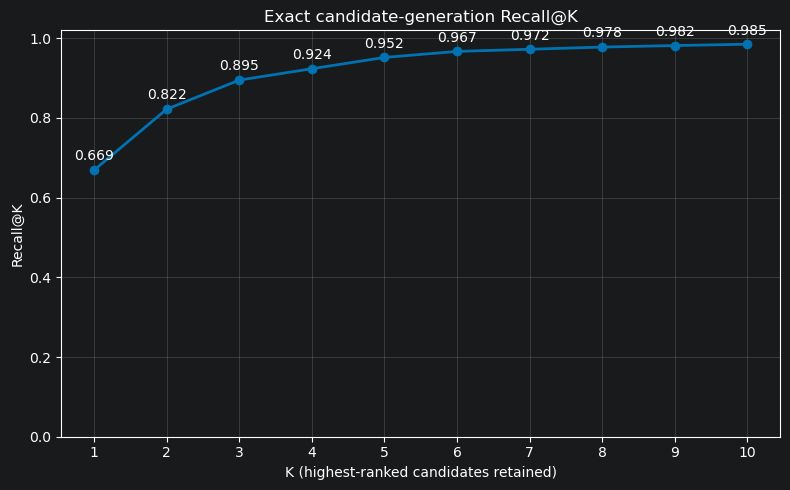

{
  "recall@1": 0.6691480562448304,
  "recall@2": 0.8220464571271023,
  "recall@3": 0.8951095947063689,
  "recall@4": 0.9236111111111112,
  "recall@5": 0.9519920044113592,
  "recall@6": 0.9670698924731183,
  "recall@7": 0.9724979321753515,
  "recall@8": 0.9779776674937966,
  "recall@9": 0.9818376068376068,
  "recall@10": 0.9851288944030879
}
C:\Users\theon\r-GCN_fusion\artifacts\Track_identification\candidate_recall_at_k.png


In [18]:
# Candidate-generation retrieval quality (evaluation only; never used as a feature).
RECALL_K_START = 1

# Graph workers determine the first exact-match rank while each optimized, enriched
# shortlist is already in memory. The parent retains only two integers per observation,
# rather than resurrecting the discarded complete scored-candidate payload.
max_candidate_count = max((count for _rank, count in candidate_recall_rank_counts), default=0)
max_recall_k = max(RECALL_K_START, max_candidate_count)
first_correct_rank = np.fromiter(
    (rank if rank else max_recall_k + 1 for rank, _count in candidate_recall_rank_counts),
    dtype=np.int32,
    count=len(candidate_recall_rank_counts),
)


if first_correct_rank.size == 0:
    raise ValueError("Recall@K requires at least one scored observation")

# A rank histogram plus cumulative sum calculates the complete curve in O(N + K).
rank_histogram = np.bincount(first_correct_rank, minlength=max_recall_k + 2)
cumulative_hits = np.cumsum(rank_histogram)
recall_k_values = np.arange(RECALL_K_START, max_recall_k + 1, dtype=np.int32)
recall_at_k = cumulative_hits[recall_k_values] / first_correct_rank.size
recall_metrics = {f"recall@{int(k)}": float(value) for k, value in zip(recall_k_values, recall_at_k)}
(ARTIFACT_DIR / "candidate_recall_at_k.json").write_text(json.dumps(recall_metrics, indent=2), encoding="utf-8")

fig, axis = plt.subplots(figsize=(8, 5))
axis.plot(recall_k_values, recall_at_k, marker="o", linewidth=2, color="#0072B2")
axis.set(
    title="Exact candidate-generation Recall@K",
    xlabel="K (highest-ranked candidates retained)",
    ylabel="Recall@K",
    xticks=recall_k_values,
    ylim=(0.0, 1.02),
)
axis.grid(True, alpha=0.3)
for k, value in zip(recall_k_values, recall_at_k):
    axis.annotate(f"{value:.3f}", (k, value), xytext=(0, 7), textcoords="offset points", ha="center")
fig.tight_layout()
recall_plot_path = ARTIFACT_DIR / "candidate_recall_at_k.png"
fig.savefig(recall_plot_path, dpi=180, bbox_inches="tight")
plt.show()
print(json.dumps(recall_metrics, indent=2))
print(recall_plot_path)


In [7]:
GRAPH_INPUT_ARTIFACT = ARTIFACT_DIR / "graph_construction_outputs.pt"

# feature_rows contains one Python dictionary per node and is already represented by X.
# Omitting it avoids pickle memoising millions of redundant dictionaries. Keep only
# the segment values needed by edge construction in a compact tensor.
observation_segment_indices = torch.tensor(
    [int(feature_rows[i]["segment_index"]) for i in observation_node_indices],
    dtype=torch.int32,
)
claim_candidate_signed_claim_index = torch.frombuffer(
    claim_candidate_signed_claim_indices, dtype=torch.int32
)
claim_candidate_node_index = torch.frombuffer(
    claim_candidate_node_indices, dtype=torch.int32
)

graph_artifact = {
    "version": 8,
    # X is already persisted by the memmap. Saving it again would duplicate the largest
    # object, consume pickle memory, and make this metadata artifact needlessly huge.
    "feature_matrix": {
        "path": GRAPH_FEATURE_MEMMAP.name,
        "shape": tuple(X.shape),
        "dtype": np.dtype(X_NP_DTYPE).str,
    },
    "feature_names": feature_names,
    "observation_segment_indices": observation_segment_indices,
    "node_meta": node_meta,
    "observation_node_indices": observation_node_indices,
    "candidates_by_observation_node": dict(candidates_by_observation_node),
    "reports_by_observation_node": dict(reports_by_observation_node),
    "claims_by_observation_node": dict(claims_by_observation_node),
    "claims_by_claim_type": dict(claims_by_claim_type),
    "claim_candidate_signed_claim_index": claim_candidate_signed_claim_index,
    "claim_candidate_node_index": claim_candidate_node_index,
    "kg_entity_node_indices": kg_entity_node_indices,
    "report_kg_edges": report_kg_edges,
    "include_candidate_nodes": INCLUDE_CANDIDATE_NODES,
    "include_intel_report_nodes": INCLUDE_INTEL_REPORT_NODES,
    "use_segment_edges": USE_SEGMENT_EDGES,
    "segment_frequency_shift_ghz": SEGMENT_FREQUENCY_SHIFT_GHZ,
    "max_kg_retrieval_candidates": MAX_KG_RETRIEVAL_CANDIDATES,
    "max_kg_candidates": MAX_KG_CANDIDATES,
}
torch.save(graph_artifact, GRAPH_INPUT_ARTIFACT)
print(X.shape, feature_names[:10], {"observation_nodes": len(observation_node_indices), "candidate_nodes": sum(map(len, candidates_by_observation_node.values())), "report_nodes": sum(1 for meta in node_meta if meta.get("node_kind") == "intelligence_report"), "claim_nodes": sum(1 for meta in node_meta if meta.get("node_kind") == "report_claim"), "claim_candidate_edges": len(claim_candidate_signed_claim_indices), "kg_entity_nodes": len(kg_entity_node_indices), "report_kg_edges": len(report_kg_edges), "artifact": str(GRAPH_INPUT_ARTIFACT)})


torch.Size([502046, 147]) ['candidate_aircraft_score', 'candidate_bandwidth_residual', 'candidate_center_frequency_residual', 'candidate_coherent_processing_interval_residual', 'candidate_compared_fields', 'candidate_count', 'candidate_duty_cycle_residual', 'candidate_dwell_time_residual', 'candidate_final_score', 'candidate_fused_match_mass'] {'observation_nodes': 58032, 'candidate_nodes': 406224, 'report_nodes': 6222, 'claim_nodes': 31110, 'claim_candidate_edges': 4754778, 'kg_entity_nodes': 458, 'report_kg_edges': 20744, 'artifact': 'C:\\Users\\theon\\r-GCN_fusion\\artifacts\\Track_identification\\graph_construction_outputs.pt'}


In [5]:
# Reload graph-construction outputs instead of rebuilding the feature and evidence nodes.
GRAPH_INPUT_ARTIFACT = ARTIFACT_DIR / "graph_construction_outputs.pt"
graph_outputs = torch.load(GRAPH_INPUT_ARTIFACT, map_location="cpu", weights_only=False)
if graph_outputs.get("version") != 8:
    raise ValueError(f"Unsupported graph-construction artifact: {GRAPH_INPUT_ARTIFACT}")
feature_matrix = graph_outputs["feature_matrix"]
feature_matrix_path = ARTIFACT_DIR / feature_matrix["path"]
X_np = np.memmap(
    feature_matrix_path, mode="r+", dtype=np.dtype(feature_matrix["dtype"]),
    shape=tuple(feature_matrix["shape"]),
)
X = torch.from_numpy(X_np)  # mini-batches cast only local nodes
feature_names = graph_outputs["feature_names"]
observation_segment_indices = graph_outputs["observation_segment_indices"]
node_meta = graph_outputs["node_meta"]
observation_node_indices = graph_outputs["observation_node_indices"]
candidates_by_observation_node = defaultdict(list, graph_outputs["candidates_by_observation_node"])
reports_by_observation_node = defaultdict(list, graph_outputs["reports_by_observation_node"])
claims_by_observation_node = defaultdict(list, graph_outputs["claims_by_observation_node"])
claims_by_claim_type = defaultdict(list, graph_outputs["claims_by_claim_type"])
claim_candidate_signed_claim_index = graph_outputs["claim_candidate_signed_claim_index"]
claim_candidate_node_index = graph_outputs["claim_candidate_node_index"]
kg_entity_node_indices = graph_outputs["kg_entity_node_indices"]
report_kg_edges = graph_outputs["report_kg_edges"]
print(f"Reloaded {X.size(0):,} nodes, {X.size(1):,} features from {GRAPH_INPUT_ARTIFACT}")


Reloaded 1,140,398 nodes, 159 features from C:\Users\theon\r-GCN_fusion\artifacts\Track_identification\graph_construction_outputs.pt


## Build the proximity- and KG-aware relational graph

The graph combines temporal track structure, candidates, report provenance, proximity-qualified report/claim links, and direct bidirectional claim-to-KG-entity links. The r-GCN/HGT can therefore distinguish report proximity, asserted domain identity, candidate support, and candidate refutation as separate relations.


In [6]:
RELATION_NAMES = ["self", "next_observation", "prev_observation", "same_emitter"]
if USE_SEGMENT_EDGES:
    RELATION_NAMES.extend(["same_mode_segment", "possible_mode_shift"])
if INCLUDE_CANDIDATE_NODES:
    RELATION_NAMES.extend(["has_candidate", "candidate_for", "contradicts_candidate"])
if INCLUDE_INTEL_REPORT_NODES:
    RELATION_NAMES.extend(["has_report", "report_for", "report_contains_claim", "claim_from_report", "claim_supports_observation", "observation_supported_by_claim", "claim_supports_candidate", "claim_refutes_candidate", "contradicts_claim", "claim_asserts_kg_entity", "kg_entity_asserted_by_claim"])
    if not COLLAPSE_RECIPROCAL_CLAIM_CANDIDATE_EDGES:
        RELATION_NAMES.extend(["candidate_supported_by_claim", "candidate_refuted_by_claim"])
RELATIONS = {name: idx for idx, name in enumerate(RELATION_NAMES)}
# Compact native integer buffers avoid one Python object per endpoint/type while this
# high-cardinality graph is assembled. Bulk extension also moves the common temporal
# and self-edge paths out of Python's per-edge append loop.
edge_src, edge_dst, edge_type = array("q"), array("q"), array("q")


def add_edges(sources, destinations, rel):
    count = len(sources)
    if count != len(destinations):
        raise ValueError("edge source and destination counts differ")
    edge_src.extend(sources)
    edge_dst.extend(destinations)
    edge_type.extend(array("q", [RELATIONS[rel]]) * count)


def add_edge(i, j, rel):
    add_edges((i,), (j,), rel)


def add_fanout(source, destinations, rel):
    add_edges(array("q", [source]) * len(destinations), destinations, rel)


node_range = range(len(node_meta))
add_edges(node_range, node_range, "self")

series_to_indices = defaultdict(list)
for i in observation_node_indices:
    series_to_indices[node_meta[i]["series_id"]].append(i)

segment_by_node = dict(zip(observation_node_indices, observation_segment_indices.tolist()))
for indices in series_to_indices.values():
    indices = sorted(indices, key=lambda i: node_meta[i]["sequence_index"])
    current, following = indices[:-1], indices[1:]
    add_edges(current, following, "next_observation")
    add_edges(following, current, "prev_observation")
    if USE_SEGMENT_EDGES:
        stable_sources, stable_destinations = array("q"), array("q")
        shift_sources, shift_destinations = array("q"), array("q")
        for a, b in zip(current, following):
            sources, destinations = (
                (stable_sources, stable_destinations)
                if segment_by_node[a] == segment_by_node[b]
                else (shift_sources, shift_destinations)
            )
            sources.extend((a, b))
            destinations.extend((b, a))
        add_edges(stable_sources, stable_destinations, "same_mode_segment")
        add_edges(shift_sources, shift_destinations, "possible_mode_shift")
    skip_sources, skip_destinations = indices[:-2], indices[2:]
    add_edges(skip_sources, skip_destinations, "same_emitter")
    add_edges(skip_destinations, skip_sources, "same_emitter")

contradiction_reasons = Counter()
if INCLUDE_CANDIDATE_NODES:
    for obs_idx, candidate_indices in candidates_by_observation_node.items():
        candidate_indices = sorted(candidate_indices, key=lambda idx: node_meta[idx]["rank"])
        add_fanout(obs_idx, candidate_indices, "has_candidate")
        add_edges(candidate_indices, array("q", [obs_idx]) * len(candidate_indices), "candidate_for")
        for left_pos, left_idx in enumerate(candidate_indices):
            contradictory = [
                right_idx for right_idx in candidate_indices[left_pos + 1:]
                if node_meta[left_idx].get("rank") != node_meta[right_idx].get("rank")
            ]
            add_fanout(left_idx, contradictory, "contradicts_candidate")
            contradiction_reasons["rank"] += len(contradictory)

claim_candidate_edges_retained = int(claim_candidate_signed_claim_index.numel())
if INCLUDE_INTEL_REPORT_NODES:
    for obs_idx, report_indices in reports_by_observation_node.items():
        for report_idx in report_indices:
            add_edge(obs_idx, report_idx, "has_report")
            add_edge(report_idx, obs_idx, "report_for")
    for obs_idx, claim_indices in claims_by_observation_node.items():
        for claim_idx in claim_indices:
            report_idx = node_meta[claim_idx]["report_node_idx"]
            add_edge(report_idx, claim_idx, "report_contains_claim")
            add_edge(claim_idx, report_idx, "claim_from_report")
            add_edge(claim_idx, obs_idx, "claim_supports_observation")
            add_edge(obs_idx, claim_idx, "observation_supported_by_claim")
    # NumPy views avoid materialising two Python-int lists for all retained edges.
    signed_claim_indices = claim_candidate_signed_claim_index.numpy()
    candidate_indices = claim_candidate_node_index.numpy()
    for positive, forward_relation, reverse_relation in (
        (True, "claim_supports_candidate", "candidate_supported_by_claim"),
        (False, "claim_refutes_candidate", "candidate_refuted_by_claim"),
    ):
        claim_indices, selected_candidates = array("q"), array("q")
        for signed_claim_index, candidate_idx in zip(signed_claim_indices, candidate_indices):
            if (signed_claim_index > 0) == positive:
                claim_indices.append(abs(signed_claim_index) - 1)
                selected_candidates.append(candidate_idx)
        add_edges(claim_indices, selected_candidates, forward_relation)
        if not COLLAPSE_RECIPROCAL_CLAIM_CANDIDATE_EDGES:
            add_edges(selected_candidates, claim_indices, reverse_relation)
    for claim_idx, kg_idx in report_kg_edges:
        add_edge(claim_idx, kg_idx, "claim_asserts_kg_entity")
        add_edge(kg_idx, claim_idx, "kg_entity_asserted_by_claim")
    for claim_indices in claims_by_claim_type.values():
        for left_pos, left_idx in enumerate(claim_indices):
            left_object = node_meta[left_idx].get("object_id")
            contradictory = [
                right_idx for right_idx in claim_indices[left_pos + 1:]
                if left_object != node_meta[right_idx].get("object_id")
            ]
            add_fanout(left_idx, contradictory, "contradicts_claim")
            contradiction_reasons["report_claim_object_id"] += len(contradictory)

# Keep the canonical edge tensors on CPU. Mini-batches transfer only induced track graphs.
edge_index = torch.stack((
    torch.from_numpy(np.frombuffer(edge_src, dtype=np.int64)),
    torch.from_numpy(np.frombuffer(edge_dst, dtype=np.int64)),
))
# frombuffer keeps the compact array alive through the tensor, so no clone-sized
# allocation is needed. Do not partition the full graph here: that would duplicate
# every endpoint merely to print counts; mini-batches are partitioned when prepared.
edge_types = torch.frombuffer(edge_type, dtype=torch.int64)
del edge_src, edge_dst, edge_type
relation_edge_counts = torch.bincount(edge_types, minlength=len(RELATIONS)).tolist()
print({name: relation_edge_counts[rid] for name, rid in RELATIONS.items()})
print({"claim_candidate_edges_retained": claim_candidate_edges_retained,
       "reciprocal_claim_candidate_edges": not COLLAPSE_RECIPROCAL_CLAIM_CANDIDATE_EDGES,
       "contradiction_reasons": dict(contradiction_reasons)})


{'self': 1140398, 'next_observation': 56782, 'prev_observation': 56782, 'same_emitter': 111064, 'has_candidate': 1044576, 'candidate_for': 1044576, 'contradicts_candidate': 8878896, 'has_report': 199903, 'report_for': 199903, 'report_contains_claim': 999515, 'claim_from_report': 999515, 'claim_supports_observation': 999515, 'observation_supported_by_claim': 999515, 'claim_supports_candidate': 4715426, 'claim_refutes_candidate': 7511088, 'contradicts_claim': 74876, 'claim_asserts_kg_entity': 20744, 'kg_entity_asserted_by_claim': 20744}
{'claim_candidate_edges_retained': 12226514, 'reciprocal_claim_candidate_edges': False, 'contradiction_reasons': {'rank': 8878896, 'report_claim_object_id': 74876}}


## Build track-level RAO and observation-level radar-mode targets

The invariant label is one joint `(aircraft_variant, radar_type, operator_country)` class per series. Radar mode remains an observation target. The 0.5/0.3/0.2 split is performed on `series_id` and stratified by the joint RAO class; no observation from a track can cross a split boundary.


In [ ]:
RAO_FIELDS = ("aircraft_variant", "radar_type", "operator_country")
MODE_TASK = "radar_mode"

def rao_tuple(values: dict[str, Any]) -> tuple[str, str, str]:
    """Normalize either track- or observation-label naming to one RAO tuple."""
    result = (
        values.get("aircraft_variant") or values.get("aircraft"),
        values.get("radar_type") or values.get("radar"),
        values.get("operator_country") or values.get("operator"),
    )
    if any(value is None for value in result):
        raise ValueError(f"Incomplete RAO target: {values}")
    return result

# Validate the invariant before training rather than silently optimizing contradictory labels.
rao_target_by_series = {
    series_id: rao_tuple(target) for series_id, target in track_targets_by_series_id.items()
}
# Check rows in one pass and retain only the first few offending IDs. Grouping
# every target-row dictionary by series duplicated a large Python container.
mismatches_by_series: dict[str, list[str]] = defaultdict(list)
for row in target_rows:
    series_id = row["series_id"]
    if rao_tuple(row) != rao_target_by_series[series_id] and len(mismatches_by_series[series_id]) < 3:
        mismatches_by_series[series_id].append(row["observation_id"])
if mismatches_by_series:
    series_id, mismatches = next(iter(mismatches_by_series.items()))
    raise ValueError(f"RAO changes inside {series_id!r}; split the track at {mismatches}")

# The RAO output vocabulary is an allow-list of KG-valid worlds, not a Cartesian product.
rao_vocab = sorted({
    tuple(world[field] for field in RAO_FIELDS)
    for world in kg_valid_worlds
})
rao_class_index = {world: index for index, world in enumerate(rao_vocab)}
unknown_targets = {value for value in rao_target_by_series.values() if value not in rao_class_index}
if unknown_targets:
    raise ValueError(f"Track targets absent from the KG-valid RAO frame: {sorted(unknown_targets)[:3]}")

mode_values = {row[MODE_TASK] for row in target_rows}
if None in mode_values:
    raise ValueError("Missing radar-mode labels are not supported")
mode_vocab = sorted(mode_values)
mode_class_index = {value: index for index, value in enumerate(mode_vocab)}

series_ids = sorted(rao_target_by_series)
series_index = {series_id: index for index, series_id in enumerate(series_ids)}
track_target_indices = np.fromiter(
    (rao_class_index[rao_target_by_series[series_id]] for series_id in series_ids),
    dtype=np.int64, count=len(series_ids),
)
mode_by_observation_id = {row["observation_id"]: row[MODE_TASK] for row in target_rows}
observation_node_array = np.asarray(observation_node_indices, dtype=np.int64)
observation_track_array = np.fromiter(
    (series_index[node_meta[node_idx]["series_id"]] for node_idx in observation_node_indices),
    dtype=np.int64, count=len(observation_node_indices),
)
mode_target_indices = np.fromiter(
    (mode_class_index[mode_by_observation_id[node_meta[node_idx]["observation_id"]]]
     for node_idx in observation_node_indices),
    dtype=np.int64, count=len(observation_node_indices),
)
# from_numpy avoids the temporary Python-int lists and the extra tensor copy made
# by torch.tensor(...); transfer each compact array to the accelerator only once.
track_targets = torch.from_numpy(track_target_indices).to(DEVICE)
observation_nodes_cpu = torch.from_numpy(observation_node_array)
observation_nodes = observation_nodes_cpu.to(DEVICE)
observation_track_index_cpu = torch.from_numpy(observation_track_array)
observation_track_index = observation_track_index_cpu.to(DEVICE)
mode_targets = torch.from_numpy(mode_target_indices).to(DEVICE)

# Compatibility[RAO, mode] is derived from the KG and is used by the conditioned mode head.
rao_mode_compatibility_array = np.zeros((len(rao_vocab), len(mode_vocab)), dtype=np.float32)
for world in kg_valid_worlds:
    rao_index = rao_class_index.get(tuple(world[field] for field in RAO_FIELDS))
    mode_index = mode_class_index.get(world[MODE_TASK])
    if rao_index is not None and mode_index is not None:
        rao_mode_compatibility_array[rao_index, mode_index] = 1.0
# Populate on the CPU and copy once: scalar assignment into a CUDA tensor launches
# one kernel per valid world and is disproportionately expensive.
rao_mode_compatibility = torch.from_numpy(rao_mode_compatibility_array).to(DEVICE)
if (rao_mode_compatibility.sum(dim=1) == 0).any():
    raise ValueError("Every RAO class must support at least one radar mode")


def stratified_track_split(labels_by_series, fractions, seed):
    split_names = tuple(fractions)
    desired = {name: fractions[name] * len(labels_by_series) for name in split_names}
    result = {name: set() for name in split_names}
    strata = defaultdict(list)
    for series_id, label in labels_by_series.items():
        strata[label].append(series_id)
    rng = np.random.default_rng(seed)
    items = list(strata.items())
    rng.shuffle(items)
    items.sort(key=lambda item: len(item[1]), reverse=True)
    for _, ids in items:
        rng.shuffle(ids)
        quota = {name: fractions[name] * len(ids) for name in split_names}
        assigned = {name: 0 for name in split_names}
        for series_id in ids:
            name = max(split_names, key=lambda key: (quota[key] - assigned[key], desired[key] - len(result[key])))
            result[name].add(series_id)
            assigned[name] += 1
    return result

split_series = stratified_track_split(rao_target_by_series, {"train": 0.5, "test": 0.3, "val": 0.2}, SEED)
# Build split membership on the CPU, where graph batching consumes it, then copy
# each small index tensor to the accelerator once. This removes a GPU round trip.
track_splits_cpu = {
    name: torch.from_numpy(np.fromiter(
        (series_index[sid] for sid in series_ids if sid in ids),
        dtype=np.int64, count=len(ids),
    ))
    for name, ids in split_series.items()
}
track_splits = {name: tracks.to(DEVICE) for name, tracks in track_splits_cpu.items()}
split_names = tuple(track_splits)
split_index_by_track = np.empty(len(series_ids), dtype=np.int8)
for split_index, name in enumerate(split_names):
    split_index_by_track[track_splits_cpu[name].numpy()] = split_index
observation_split_indices = split_index_by_track[observation_track_array]
# Direct integer lookup is O(observations); torch.isin scanned the observation
# vector once per split and allocated a full-sized temporary mask each time.
observation_splits = {
    name: torch.from_numpy(np.flatnonzero(observation_split_indices == split_index)).to(DEVICE)
    for split_index, name in enumerate(split_names)
}
for name in track_splits:
    print(name, {"tracks": int(track_splits[name].numel()), "observations": int(observation_splits[name].numel())})
print({"rao_classes": len(rao_vocab), "mode_classes": len(mode_vocab)})

# Every non-KG node belongs to exactly one track; shared KG nodes use -1.
node_track_index = torch.from_numpy(np.fromiter(
    (series_index.get(meta.get("series_id"), -1) for meta in node_meta),
    dtype=np.int64, count=len(node_meta),
))
TRACKS_PER_BATCH = max(1, int(os.getenv("TRACKS_PER_BATCH", "16")))
# Index edge/observation ownership once for all splits. The former per-split calls
# repeatedly scanned every graph edge and every observation for every mini-batch.
batches_by_split = build_track_graph_batches_by_split(
    edge_index=edge_index, edge_types=edge_types, node_track_index=node_track_index,
    observation_nodes=observation_nodes_cpu, observation_track_index=observation_track_index_cpu,
    selected_tracks_by_split=track_splits_cpu, tracks_per_batch=TRACKS_PER_BATCH,
)
print({"tracks_per_batch": TRACKS_PER_BATCH,
       "split_batches": {name: len(batches) for name, batches in batches_by_split.items()}})


## Hierarchical relation-aware encoder, track pool, and constrained output heads

The graph encoder is retained, but its observation embeddings are pooled by `series_id`. `TrackAttentionPool` returns one track vector. A single joint RAO head operates on those vectors, making within-track identity changes impossible by construction. The radar-mode head operates on each observation and receives its broadcast track vector plus a differentiable KG compatibility prior marginalized over the soft RAO distribution.


In [8]:
MAXIMUM_HIDDEN_DIM = 120
MINIMUM_HIDDEN_DIM = 80
NUM_MESSAGE_PASSING_EDGES = 20
NUM_RGCN_BASES = 6
NUM_HGT_LAYERS = 3
NUM_ATTENTION_HEADS = 5
DROPOUT = 0.35
TASK_HEAD_HIDDEN_DIM = 90
EVIDENTIAL_LOSS_WEIGHT = 0.85
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
L1_LAMBDA = 1e-4
PATIENCE = 10
EARLY_STOPPING_MIN_DELTA = 1e-4
EDGE_CHUNK_SIZE = 2_500_000
METRICS_INTERVAL = max(1, int(os.getenv("METRICS_INTERVAL", "10")))
# Pinning every cached graph tensor can exhaust the CUDA host allocator on large graphs.
# Keep the memory-safe pageable path by default; opt in only when the host has ample RAM.
PIN_BATCH_MEMORY = DEVICE.type == "cuda" and os.getenv("PIN_BATCH_MEMORY", "0") == "1"

MODEL_DTYPE = torch.float32
USE_AMP = DEVICE.type == "cuda"
AMP_DTYPE = torch.float16
GRADIENT_CHECKPOINTING = DEVICE.type == "cuda"

if NUM_MESSAGE_PASSING_EDGES < 1:
    raise ValueError("NUM_MESSAGE_PASSING_EDGES must be at least 1.")
if MINIMUM_HIDDEN_DIM < 1 or MAXIMUM_HIDDEN_DIM < MINIMUM_HIDDEN_DIM:
    raise ValueError("Hidden dimensions must satisfy 1 <= MINIMUM_HIDDEN_DIM <= MAXIMUM_HIDDEN_DIM.")
if MINIMUM_HIDDEN_DIM % NUM_ATTENTION_HEADS != 0:
    raise ValueError("MINIMUM_HIDDEN_DIM must be divisible by NUM_ATTENTION_HEADS for HGT attention.")


class RelationalGraphConvolutionBlock(nn.Module):
    """Residual r-GCN aggregation over prepartitioned relation edge tensors."""
    def __init__(self, in_dim, out_dim, num_relations, num_bases, dropout, edge_chunk_size=0):
        super().__init__()
        self.num_relations = max(int(num_relations), 1)
        self.num_bases = min(max(int(num_bases), 1), self.num_relations)
        self.bases = nn.Parameter(torch.empty(self.num_bases, in_dim, out_dim))
        self.coefficients = nn.Parameter(torch.empty(self.num_relations, self.num_bases))
        self.root = nn.Linear(in_dim, out_dim, bias=False)
        self.bias = nn.Parameter(torch.zeros(out_dim))
        self.residual = nn.Identity() if in_dim == out_dim else nn.Linear(in_dim, out_dim, bias=False)
        self.norm = nn.LayerNorm(out_dim)
        self.dropout = nn.Dropout(dropout)
        if edge_chunk_size < 0:
            raise ValueError("edge_chunk_size must be non-negative")
        self.edge_chunk_size = int(edge_chunk_size)
        nn.init.xavier_uniform_(self.bases)
        nn.init.xavier_uniform_(self.coefficients)

    def forward(self, x, relation_edges):
        messages = x.new_zeros((x.size(0), self.bases.size(-1)))
        degree = x.new_zeros(x.size(0))
        relation_weights = torch.einsum("rb,bio->rio", self.coefficients, self.bases)
        for relation_id, edges in enumerate(relation_edges):
            if edges.numel() == 0:
                continue
            relation_src, relation_dst = edges
            chunk_size = self.edge_chunk_size or int(relation_src.numel())
            for chunk_start in range(0, int(relation_src.numel()), chunk_size):
                chunk_src = relation_src[chunk_start:chunk_start + chunk_size]
                chunk_dst = relation_dst[chunk_start:chunk_start + chunk_size]
                transformed = x[chunk_src] @ relation_weights[relation_id]
                messages.index_add_(0, chunk_dst, transformed.to(messages.dtype))
                degree.index_add_(0, chunk_dst, torch.ones_like(chunk_dst, dtype=x.dtype))
        messages = messages / degree.clamp_min(1).unsqueeze(-1)
        updated = self.dropout(F.gelu(self.root(x) + messages + self.bias))
        return self.norm(self.residual(x) + updated)


class RelationAwareHGTLayer(nn.Module):
    """HGT-style attention over relation tensors partitioned before training."""
    def __init__(self, hidden_dim, num_relations, num_heads, dropout, edge_chunk_size=0):
        super().__init__()
        if hidden_dim % num_heads != 0:
            raise ValueError("hidden_dim must be divisible by num_heads")
        self.num_relations, self.num_heads = max(num_relations, 1), num_heads
        self.head_dim = hidden_dim // num_heads
        self.query, self.key, self.value = (nn.Linear(hidden_dim, hidden_dim) for _ in range(3))
        self.relation_key = nn.Parameter(torch.empty(self.num_relations, num_heads, self.head_dim, self.head_dim))
        self.relation_value = nn.Parameter(torch.empty(self.num_relations, num_heads, self.head_dim, self.head_dim))
        self.relation_priority = nn.Parameter(torch.ones(self.num_relations, num_heads))
        self.output = nn.Linear(hidden_dim, hidden_dim)
        self.norm, self.dropout = nn.LayerNorm(hidden_dim), nn.Dropout(dropout)
        self.edge_chunk_size = int(edge_chunk_size)
        nn.init.xavier_uniform_(self.relation_key)
        nn.init.xavier_uniform_(self.relation_value)

    def _edge_messages(self, x, src, dst, relation_id):
        q = self.query(x[dst]).view(-1, self.num_heads, self.head_dim)
        k = self.key(x[src]).view(-1, self.num_heads, self.head_dim)
        v = self.value(x[src]).view(-1, self.num_heads, self.head_dim)
        k = torch.einsum("ehd,hdf->ehf", k, self.relation_key[relation_id])
        v = torch.einsum("ehd,hdf->ehf", v, self.relation_value[relation_id])
        scores = (q * k).sum(-1) * self.relation_priority[relation_id] / math.sqrt(self.head_dim)
        return (torch.sigmoid(scores).unsqueeze(-1) * v).reshape(src.numel(), -1)

    def forward(self, x, relation_edges):
        messages, degree = torch.zeros_like(x), x.new_zeros(x.size(0))
        for relation_id, edges in enumerate(relation_edges):
            if edges.numel() == 0:
                continue
            rel_src, rel_dst = edges
            chunk_size = self.edge_chunk_size or int(rel_src.numel())
            for start in range(0, int(rel_src.numel()), chunk_size):
                chunk_src, chunk_dst = rel_src[start:start + chunk_size], rel_dst[start:start + chunk_size]
                messages.index_add_(0, chunk_dst, self._edge_messages(x, chunk_src, chunk_dst, relation_id).to(messages.dtype))
                degree.index_add_(0, chunk_dst, torch.ones_like(chunk_dst, dtype=x.dtype))
        updated = self.dropout(F.gelu(self.output(messages / degree.clamp_min(1).unsqueeze(-1))))
        return self.norm(x + updated)


class TrackAttentionPool(nn.Module):
    """Vectorised gated attention normalized independently inside each track."""
    def __init__(self, hidden_dim, dropout):
        super().__init__()
        self.score = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.Tanh(), nn.Dropout(dropout), nn.Linear(hidden_dim, 1))
        self.summary = nn.Sequential(nn.Linear(3 * hidden_dim, hidden_dim), nn.GELU(), nn.Dropout(dropout))
        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, observations, observation_to_track, num_tracks):
        counts = torch.bincount(observation_to_track, minlength=num_tracks)
        if torch.any(counts == 0):
            raise ValueError("Every mini-batch track must contain an observation")
        weights = segment_softmax(self.score(observations).squeeze(-1), observation_to_track, num_tracks)
        attentive = observations.new_zeros((num_tracks, observations.size(1)))
        means = torch.zeros_like(attentive)
        attentive_contributions = (weights.unsqueeze(-1) * observations).to(attentive.dtype)
        attentive.index_add_(0, observation_to_track, attentive_contributions)
        means.index_add_(0, observation_to_track, observations.to(means.dtype))
        means = means / counts.to(observations.dtype).unsqueeze(-1)
        maxima = observations.new_full(attentive.shape, -torch.inf)
        maxima.scatter_reduce_(0, observation_to_track[:, None].expand_as(observations), observations.to(maxima.dtype), reduce="amax", include_self=True)
        return self.norm(attentive + self.summary(torch.cat((attentive, means, maxima), dim=-1)))


class TrackRGCNHGTClassifier(nn.Module):
    """One KG-valid RAO opinion per track and one conditioned mode opinion per observation."""
    def __init__(self, in_dim, maximum_hidden_dim, minimum_hidden_dim, num_relations, num_rao_classes, num_mode_classes,
                 rao_mode_compatibility, num_message_passing_edges=7, num_rgcn_bases=4, num_hgt_layers=2,
                 num_heads=4, dropout=0.2, task_head_hidden_dim=128, edge_chunk_size=0, gradient_checkpointing=False):
        super().__init__()
        span = maximum_hidden_dim - minimum_hidden_dim
        self.rgcn_hidden_dims = [maximum_hidden_dim] if num_message_passing_edges == 1 else [round(maximum_hidden_dim - span * i / (num_message_passing_edges - 1)) for i in range(num_message_passing_edges)]
        self.input_projection = nn.Sequential(nn.Linear(in_dim, maximum_hidden_dim), nn.LayerNorm(maximum_hidden_dim), nn.GELU(), nn.Dropout(dropout))
        inputs = [maximum_hidden_dim, *self.rgcn_hidden_dims[:-1]]
        self.rgcn_layers = nn.ModuleList([RelationalGraphConvolutionBlock(a, b, num_relations, num_rgcn_bases, dropout, edge_chunk_size) for a, b in zip(inputs, self.rgcn_hidden_dims)])
        hidden_dim = self.rgcn_hidden_dims[-1]
        self.hgt_layers = nn.ModuleList([RelationAwareHGTLayer(hidden_dim, num_relations, num_heads, dropout, edge_chunk_size) for _ in range(num_hgt_layers)])
        self.gradient_checkpointing = bool(gradient_checkpointing)
        self.track_pool = TrackAttentionPool(hidden_dim, dropout)
        def head(in_features, out_features):
            return nn.Sequential(nn.Linear(in_features, task_head_hidden_dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(task_head_hidden_dim, out_features))
        self.rao_head, self.rao_evidential_head = head(hidden_dim, num_rao_classes), head(hidden_dim, num_rao_classes)
        self.mode_head = head(2 * hidden_dim, num_mode_classes)
        self.mode_evidential_head = head(2 * hidden_dim, num_mode_classes)
        self.register_buffer("rao_mode_compatibility", rao_mode_compatibility.float())

    @staticmethod
    def dirichlet_ds_output(evidence_logits):
        evidence = F.softplus(evidence_logits)
        alpha = evidence + 1.0
        strength = alpha.sum(-1, keepdim=True)
        return {"evidence": evidence, "alpha": alpha, "strength": strength, "probabilities": alpha / strength,
                "belief": evidence / strength, "uncertainty": evidence.size(-1) / strength}

    def encode(self, x, relation_edges):
        h = self.input_projection(x)
        for layer in [*self.rgcn_layers, *self.hgt_layers]:
            if self.gradient_checkpointing and self.training:
                h = torch.utils.checkpoint.checkpoint(lambda values, active=layer: active(values, relation_edges), h, use_reentrant=False)
            else:
                h = layer(h, relation_edges)
        return h

    def forward(self, x, relation_edges, observation_nodes, observation_to_track, num_tracks):
        node_embeddings = self.encode(x, relation_edges)
        observation_embeddings = node_embeddings[observation_nodes]
        track_embeddings = self.track_pool(observation_embeddings, observation_to_track, num_tracks)
        rao_logits = self.rao_head(track_embeddings)
        rao_evidential = self.dirichlet_ds_output(self.rao_evidential_head(track_embeddings))
        mode_features = torch.cat((observation_embeddings, track_embeddings[observation_to_track]), dim=-1)
        compatibility = torch.softmax(rao_logits, dim=-1) @ self.rao_mode_compatibility
        bias = compatibility[observation_to_track].clamp_min(1e-8).log()
        mode_logits = self.mode_head(mode_features) + bias
        return {"track_rao": rao_logits, "radar_mode": mode_logits,
                "evidential": {"track_rao": rao_evidential,
                                "radar_mode": self.dirichlet_ds_output(self.mode_evidential_head(mode_features) + bias)},
                "track_embeddings": track_embeddings, "observation_embeddings": observation_embeddings}

model_config = {"architecture": "track_minibatched_hierarchical_rao_and_mode", "maximum_hidden_dim": MAXIMUM_HIDDEN_DIM,
                "minimum_hidden_dim": MINIMUM_HIDDEN_DIM, "num_message_passing_edges": NUM_MESSAGE_PASSING_EDGES,
                "num_rgcn_bases": NUM_RGCN_BASES, "num_hgt_layers": NUM_HGT_LAYERS,
                "num_attention_heads": NUM_ATTENTION_HEADS, "dropout": DROPOUT,
                "task_head_hidden_dim": TASK_HEAD_HIDDEN_DIM, "rao_classes": len(rao_vocab),
                "radar_mode_classes": len(mode_vocab), "tracks_per_batch": TRACKS_PER_BATCH,
                "claim_candidate_min_abs_contribution": CLAIM_CANDIDATE_MIN_ABS_CONTRIBUTION,
                "reciprocal_claim_candidate_edges": not COLLAPSE_RECIPROCAL_CLAIM_CANDIDATE_EDGES,
                "rao_invariance": "one pooled output per series_id",
                "mode_conditioning": "local observation + pooled track + soft KG compatibility"}
model = TrackRGCNHGTClassifier(X.size(1), MAXIMUM_HIDDEN_DIM, MINIMUM_HIDDEN_DIM, len(RELATIONS), len(rao_vocab), len(mode_vocab), rao_mode_compatibility,
    num_message_passing_edges=NUM_MESSAGE_PASSING_EDGES, num_rgcn_bases=NUM_RGCN_BASES,
    num_hgt_layers=NUM_HGT_LAYERS, num_heads=NUM_ATTENTION_HEADS, dropout=DROPOUT,
    task_head_hidden_dim=TASK_HEAD_HIDDEN_DIM, edge_chunk_size=EDGE_CHUNK_SIZE,
    gradient_checkpointing=GRADIENT_CHECKPOINTING).to(device=DEVICE, dtype=MODEL_DTYPE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP and AMP_DTYPE == torch.float16)
print(model_config)


{'architecture': 'track_minibatched_hierarchical_rao_and_mode', 'maximum_hidden_dim': 120, 'minimum_hidden_dim': 80, 'num_message_passing_edges': 20, 'num_rgcn_bases': 6, 'num_hgt_layers': 3, 'num_attention_heads': 5, 'dropout': 0.35, 'task_head_hidden_dim': 90, 'rao_classes': 184, 'radar_mode_classes': 5, 'tracks_per_batch': 16, 'claim_candidate_min_abs_contribution': 0.15, 'reciprocal_claim_candidate_edges': False, 'rao_invariance': 'one pooled output per series_id', 'mode_conditioning': 'local observation + pooled track + soft KG compatibility'}


In [9]:
# Estimate computation after thresholding and reciprocal-edge collapse.
def estimate_edge_computation_requirements(relation_edge_counts, *, num_rgcn_layers, num_hgt_layers):
    counts_by_name = {name: relation_edge_counts[relation_id] for name, relation_id in RELATIONS.items()}
    edge_count = sum(counts_by_name.values())
    max_relation_edges = max(counts_by_name.values(), default=0)
    return {"node_count": len(node_meta), "edge_count": edge_count,
            "num_rgcn_layers": num_rgcn_layers, "num_hgt_layers": num_hgt_layers,
            "max_relation_edges_per_layer": max_relation_edges,
            "total_edge_computations_per_full_pass": (num_rgcn_layers + num_hgt_layers) * edge_count,
            "note": "Training processes induced track mini-batches; edges are partitioned once by relation.",
            "relation_edge_counts": counts_by_name}

edge_compute_requirements = estimate_edge_computation_requirements(
    relation_edge_counts, num_rgcn_layers=NUM_MESSAGE_PASSING_EDGES, num_hgt_layers=NUM_HGT_LAYERS)
for key, value in edge_compute_requirements.items():
    if key != "relation_edge_counts":
        print(f"{key}: {value:,}" if isinstance(value, int) else f"{key}: {value}")
print("relation_edge_counts:")
for relation_name, count in edge_compute_requirements["relation_edge_counts"].items():
    print(f"  {relation_name}: {count:,}")


node_count: 1,140,398
edge_count: 29,073,818
num_rgcn_layers: 20
num_hgt_layers: 3
max_relation_edges_per_layer: 8,878,896
total_edge_computations_per_full_pass: 668,697,814
note: Training processes induced track mini-batches; edges are partitioned once by relation.
relation_edge_counts:
  self: 1,140,398
  next_observation: 56,782
  prev_observation: 56,782
  same_emitter: 111,064
  has_candidate: 1,044,576
  candidate_for: 1,044,576
  contradicts_candidate: 8,878,896
  has_report: 199,903
  report_for: 199,903
  report_contains_claim: 999,515
  claim_from_report: 999,515
  claim_supports_observation: 999,515
  observation_supported_by_claim: 999,515
  claim_supports_candidate: 4,715,426
  claim_refutes_candidate: 7,511,088
  contradicts_claim: 74,876
  claim_asserts_kg_entity: 20,744
  kg_entity_asserted_by_claim: 20,744


## Train once per full graph with track-balanced supervision

Each epoch performs one relational forward pass per track mini-batch. The RAO objective retains exact joint-class loss while adding an evenly weighted mean of aircraft, radar, and operator marginal losses. Consequently, a prediction that gets only part of the KG-valid RAO tuple right still receives credit for those correct components, while the model continues to emit a single valid joint RAO class. Named configuration variables control both the complete-versus-component contributions and the relative importance of the three components without requiring loss rewrites. Mode loss is first averaged within each track and then across tracks, preventing long series from dominating. Expected Dirichlet cross-entropy is supplemented by an annealed KL penalty on incorrect evidence. Checkpoint selection uses the hierarchical validation loss.


In [ ]:
# Conservative memory preflight uses the largest induced mini-batch, not the full graph.
ENFORCE_GPU_MEMORY_CHECK = True
GPU_MEMORY_SAFETY_FACTOR = 1.50

def estimate_peak_training_gpu_memory():
    parameter_bytes = sum(parameter.numel() * parameter.element_size() for parameter in model.parameters())
    maximum_batch_nodes = max(
        batch.node_indices.numel()
        for split_batches in batches_by_split.values()
        for batch in split_batches
    )
    activation_bytes = maximum_batch_nodes * max(model.rgcn_hidden_dims) * 4 * (len(model.rgcn_layers) + len(model.hgt_layers) + 2)
    estimate = int((parameter_bytes * 4 + activation_bytes) * GPU_MEMORY_SAFETY_FACTOR)
    if DEVICE.type != "cuda":
        return {"gpu_available": False, "maximum_batch_nodes": maximum_batch_nodes,
                "estimated_peak_bytes": estimate, "training_can_start": True,
                "reason": "CUDA unavailable; CPU training remains permitted."}
    free_bytes, total_bytes = torch.cuda.mem_get_info(DEVICE)
    sufficient = estimate <= free_bytes
    return {"gpu_available": True, "device": torch.cuda.get_device_name(DEVICE),
            "maximum_batch_nodes": maximum_batch_nodes, "estimated_peak_bytes": estimate,
            "currently_free_bytes": free_bytes, "total_bytes": total_bytes, "sufficient": sufficient,
            "training_can_start": sufficient if ENFORCE_GPU_MEMORY_CHECK else True}

gpu_memory_preflight = estimate_peak_training_gpu_memory()
TRAINING_CAN_START = bool(gpu_memory_preflight["training_can_start"])
print(gpu_memory_preflight)
if not TRAINING_CAN_START:
    raise RuntimeError("GPU memory preflight blocked training; lower TRACKS_PER_BATCH or disable the conservative check explicitly")


In [ ]:
from torch.utils.tensorboard import SummaryWriter

RAO_CLASSIFICATION_WEIGHT = 1.0
MODE_CLASSIFICATION_WEIGHT = 0.01
# Relative contributions of exact joint-RAO and partial component supervision.
RAO_COMPLETE_LOSS_WEIGHT = 1.0
RAO_COMPONENT_LOSS_WEIGHT = 1.0
# Relative contributions of correct RAO components; these are normalized in the loss.
RAO_AIRCRAFT_LOSS_WEIGHT = 1.0
RAO_RADAR_LOSS_WEIGHT = 1.0
RAO_OPERATOR_LOSS_WEIGHT = 1.0
RAO_EVIDENTIAL_WEIGHT = 0.1
MODE_EVIDENTIAL_WEIGHT = 0.1
EVIDENTIAL_KL_WEIGHT = 0.1
EVIDENTIAL_KL_ANNEAL_EPOCHS = 5


def expected_dirichlet_ce(alpha, labels):
    return torch.digamma(alpha.sum(-1)) - torch.digamma(alpha.gather(1, labels[:, None]).squeeze(1))


# Rows are joint RAO classes and columns are independently supervised RAO components.
rao_component_values = [sorted({world[index] for world in rao_vocab}) for index in range(len(RAO_FIELDS))]
rao_component_ids = torch.tensor([
    [rao_component_values[index].index(world[index]) for index in range(len(RAO_FIELDS))]
    for world in rao_vocab
], dtype=torch.long, device=DEVICE)
rao_component_loss_weights = torch.tensor([
    RAO_AIRCRAFT_LOSS_WEIGHT, RAO_RADAR_LOSS_WEIGHT, RAO_OPERATOR_LOSS_WEIGHT
], dtype=torch.float32, device=DEVICE)
if (rao_component_loss_weights < 0).any() or rao_component_loss_weights.sum() <= 0:
    raise ValueError("RAO component loss weights must be non-negative with a positive sum")
rao_component_loss_weights /= rao_component_loss_weights.sum()

rao_loss_weights = torch.tensor([
    RAO_COMPLETE_LOSS_WEIGHT, RAO_COMPONENT_LOSS_WEIGHT
], dtype=torch.float32, device=DEVICE)
if (rao_loss_weights < 0).any() or rao_loss_weights.sum() <= 0:
    raise ValueError("Complete and component RAO loss weights must be non-negative with a positive sum")
rao_loss_weights /= rao_loss_weights.sum()


def component_weighted_rao_nll(logits, labels):
    """Return per-track NLLs for aircraft, radar, and operator marginals."""
    log_probabilities = F.log_softmax(logits, dim=-1)
    true_components = rao_component_ids[labels]
    component_losses = []
    for component_index in range(len(RAO_FIELDS)):
        matching_worlds = rao_component_ids[:, component_index].unsqueeze(0) == true_components[:, component_index].unsqueeze(1)
        marginal_log_probability = torch.logsumexp(log_probabilities.masked_fill(~matching_worlds, -torch.inf), dim=1)
        component_losses.append(-marginal_log_probability)
    return torch.stack(component_losses, dim=1)


def component_weighted_rao_edl(alpha, labels):
    """Return per-track expected NLLs for the three RAO marginals."""
    true_components = rao_component_ids[labels]
    component_losses = []
    total_evidence = alpha.sum(dim=1)
    for component_index in range(len(RAO_FIELDS)):
        matching_worlds = rao_component_ids[:, component_index].unsqueeze(0) == true_components[:, component_index].unsqueeze(1)
        matching_evidence = (alpha * matching_worlds.to(alpha.dtype)).sum(dim=1)
        component_losses.append(torch.digamma(total_evidence) - torch.digamma(matching_evidence))
    return torch.stack(component_losses, dim=1)


def combined_rao_nll(logits, labels):
    """Blend exact joint-class NLL with partial component-marginal NLL."""
    complete_loss = F.cross_entropy(logits, labels, reduction="none")
    component_loss = (component_weighted_rao_nll(logits, labels) * rao_component_loss_weights).sum(dim=1)
    return rao_loss_weights[0] * complete_loss + rao_loss_weights[1] * component_loss


def combined_rao_edl(alpha, labels):
    """Blend exact and component-marginal expected Dirichlet NLL."""
    complete_loss = expected_dirichlet_ce(alpha, labels)
    component_loss = (component_weighted_rao_edl(alpha, labels) * rao_component_loss_weights).sum(dim=1)
    return rao_loss_weights[0] * complete_loss + rao_loss_weights[1] * component_loss


def dirichlet_kl_to_uniform(alpha):
    classes = alpha.size(-1)
    total = alpha.sum(-1)
    return (torch.lgamma(total) - torch.lgamma(alpha).sum(-1) - torch.lgamma(alpha.new_tensor(float(classes)))
            + ((alpha - 1.0) * (torch.digamma(alpha) - torch.digamma(total).unsqueeze(-1))).sum(-1))


def suppress_true_class_evidence(alpha, labels):
    mask = F.one_hot(labels, alpha.size(-1)).to(alpha.dtype)
    return alpha * (1.0 - mask) + mask


def track_balanced_mean(values, local_observation_tracks, num_tracks):
    totals = values.new_zeros(num_tracks)
    totals.index_add_(0, local_observation_tracks, values.to(totals.dtype))
    counts = torch.bincount(local_observation_tracks, minlength=num_tracks).to(values.dtype)
    return (totals / counts.clamp_min(1)).mean()


def batch_hierarchical_loss(outputs, batch, kl_coefficient=0.0):
    tracks = batch.track_indices.to(DEVICE)
    positions = batch.observation_positions.to(DEVICE)
    local_tracks = batch.observation_to_track.to(DEVICE)
    rao_labels, mode_labels = track_targets[tracks], mode_targets[positions]
    rao_ce = combined_rao_nll(outputs["track_rao"], rao_labels).mean()
    rao_component_ce = component_weighted_rao_nll(outputs["track_rao"], rao_labels).mean(dim=0)
    mode_ce = track_balanced_mean(F.cross_entropy(outputs["radar_mode"], mode_labels, reduction="none"), local_tracks, tracks.numel())
    rao_alpha, mode_alpha = outputs["evidential"]["track_rao"]["alpha"], outputs["evidential"]["radar_mode"]["alpha"]
    rao_edl = combined_rao_edl(rao_alpha, rao_labels).mean()
    rao_component_expected = component_weighted_rao_edl(rao_alpha, rao_labels).mean(dim=0)
    mode_edl = track_balanced_mean(expected_dirichlet_ce(mode_alpha, mode_labels), local_tracks, tracks.numel())
    rao_kl = dirichlet_kl_to_uniform(suppress_true_class_evidence(rao_alpha, rao_labels)).mean()
    mode_kl = track_balanced_mean(dirichlet_kl_to_uniform(suppress_true_class_evidence(mode_alpha, mode_labels)), local_tracks, tracks.numel())
    loss = (RAO_CLASSIFICATION_WEIGHT * rao_ce + MODE_CLASSIFICATION_WEIGHT * mode_ce
            + RAO_EVIDENTIAL_WEIGHT * rao_edl + MODE_EVIDENTIAL_WEIGHT * mode_edl
            + kl_coefficient * (rao_kl + mode_kl))
    component_diagnostics = {
        f"rao_{field}_loss": rao_component_ce[index] + RAO_EVIDENTIAL_WEIGHT * rao_component_expected[index]
        for index, field in enumerate(("aircraft", "radar", "operator"))
    }
    return loss, {"rao_ce": rao_ce, "mode_ce": mode_ce, "rao_edl": rao_edl, "mode_edl": mode_edl,
                  "rao_kl": rao_kl, "mode_kl": mode_kl, **component_diagnostics}


def _pin_for_cuda(tensor):
    # Pinned host pages accelerate CUDA transfers, but caching every graph batch in
    # pinned memory can exhaust the CUDA host allocator before training starts.
    return tensor.pin_memory() if PIN_BATCH_MEMORY else tensor


def prepare_batches(batches):
    prepared = []
    for batch in batches:
        # Cache the costly advanced-index selection once instead of rebuilding it in
        # every epoch. Split batches are disjoint, so this does not duplicate X.
        local_x = _pin_for_cuda(X[batch.node_indices].to(dtype=MODEL_DTYPE).contiguous())
        relation_edges = tuple(
            _pin_for_cuda(edges.contiguous())
            for edges in partition_edges_by_relation(batch.edge_index, batch.edge_types, len(RELATIONS))
        )
        device_indices = tuple(
            _pin_for_cuda(tensor.contiguous())
            for tensor in (batch.observation_nodes, batch.observation_to_track, batch.track_indices,
                           batch.observation_positions)
        )
        prepared.append((batch, local_x, relation_edges, device_indices))
    return prepared


prepared_batches_by_split = {name: prepare_batches(batches) for name, batches in batches_by_split.items()}


def model_forward_batch(prepared_batch):
    batch, local_x, batch_relation_edges, device_indices = prepared_batch
    observation_nodes, observation_to_track, _tracks, _positions = (
        tensor.to(DEVICE, non_blocking=True) for tensor in device_indices
    )
    local_edges = tuple(edges.to(DEVICE, non_blocking=True) for edges in batch_relation_edges)
    return model(local_x.to(DEVICE, non_blocking=True), local_edges, observation_nodes,
                 observation_to_track, batch.track_indices.numel())


def model_forward(prepared_batches=None):
    """Run selected deterministic mini-batches and scatter outputs into global order."""
    if prepared_batches is None:
        prepared_batches = [item for name in ("train", "test", "val")
                            for item in prepared_batches_by_split[name]]
    gathered = None
    for prepared_batch in prepared_batches:
        batch = prepared_batch[0]
        output = model_forward_batch(prepared_batch)
        if gathered is None:
            hidden_dim = output["track_embeddings"].size(1)
            gathered = {
                "track_rao": output["track_rao"].new_empty((len(series_ids), len(rao_vocab))),
                "radar_mode": output["radar_mode"].new_empty((len(observation_node_indices), len(mode_vocab))),
                "track_embeddings": output["track_embeddings"].new_empty((len(series_ids), hidden_dim)),
                "observation_embeddings": output["observation_embeddings"].new_empty((len(observation_node_indices), hidden_dim)),
                "evidential": {task: {key: value.new_empty(((len(series_ids) if task == "track_rao" else len(observation_node_indices)), *value.shape[1:]))
                                      for key, value in output["evidential"][task].items()}
                                for task in ("track_rao", "radar_mode")},
            }
        tracks, positions = (
            tensor.to(DEVICE, non_blocking=True) for tensor in prepared_batch[3][2:]
        )
        gathered["track_rao"][tracks] = output["track_rao"]
        gathered["radar_mode"][positions] = output["radar_mode"]
        gathered["track_embeddings"][tracks] = output["track_embeddings"]
        gathered["observation_embeddings"][positions] = output["observation_embeddings"]
        for key, value in output["evidential"]["track_rao"].items():
            gathered["evidential"]["track_rao"][key][tracks] = value
        for key, value in output["evidential"]["radar_mode"].items():
            gathered["evidential"]["radar_mode"][key][positions] = value
    return gathered


def mean_modes_per_track(values, observation_positions, selected_tracks):
    selected_track_ids = observation_track_index[observation_positions]
    local_lookup = torch.full((len(series_ids),), -1, dtype=torch.long, device=DEVICE)
    local_lookup[selected_tracks] = torch.arange(selected_tracks.numel(), device=DEVICE)
    return track_balanced_mean(values, local_lookup[selected_track_ids], selected_tracks.numel())


def hierarchical_loss(outputs, split_name, kl_coefficient=0.0):
    tracks, observations = track_splits[split_name], observation_splits[split_name]
    rao_labels, mode_labels = track_targets[tracks], mode_targets[observations]
    rao_ce = combined_rao_nll(outputs["track_rao"][tracks], rao_labels).mean()
    rao_component_ce = component_weighted_rao_nll(outputs["track_rao"][tracks], rao_labels).mean(dim=0)
    mode_ce = mean_modes_per_track(F.cross_entropy(outputs["radar_mode"][observations], mode_labels, reduction="none"), observations, tracks)
    rao_alpha = outputs["evidential"]["track_rao"]["alpha"][tracks]
    mode_alpha = outputs["evidential"]["radar_mode"]["alpha"][observations]
    rao_edl = combined_rao_edl(rao_alpha, rao_labels).mean()
    rao_component_expected = component_weighted_rao_edl(rao_alpha, rao_labels).mean(dim=0)
    mode_edl = mean_modes_per_track(expected_dirichlet_ce(mode_alpha, mode_labels), observations, tracks)
    rao_kl = dirichlet_kl_to_uniform(suppress_true_class_evidence(rao_alpha, rao_labels)).mean()
    mode_kl = mean_modes_per_track(dirichlet_kl_to_uniform(suppress_true_class_evidence(mode_alpha, mode_labels)), observations, tracks)
    loss = (RAO_CLASSIFICATION_WEIGHT * rao_ce + MODE_CLASSIFICATION_WEIGHT * mode_ce
            + RAO_EVIDENTIAL_WEIGHT * rao_edl + MODE_EVIDENTIAL_WEIGHT * mode_edl
            + kl_coefficient * (rao_kl + mode_kl))
    component_diagnostics = {
        f"rao_{field}_loss": rao_component_ce[index] + RAO_EVIDENTIAL_WEIGHT * rao_component_expected[index]
        for index, field in enumerate(("aircraft", "radar", "operator"))
    }
    return loss, {"rao_ce": rao_ce, "mode_ce": mode_ce, "rao_edl": rao_edl, "mode_edl": mode_edl,
                  "rao_kl": rao_kl, "mode_kl": mode_kl, **component_diagnostics}


def accuracy(logits, labels):
    return float((logits.argmax(-1) == labels).float().mean().detach().cpu())


def rao_component_accuracies(logits, labels):
    """Report aircraft, radar, and operator accuracy from joint RAO predictions."""
    predicted_components = rao_component_ids[logits.argmax(dim=-1)]
    target_components = rao_component_ids[labels]
    component_accuracy = (
        (predicted_components == target_components).float().mean(dim=0).detach().cpu().tolist()
    )
    return {
        "rao_aircraft_acc": component_accuracy[0],
        "rao_radar_acc": component_accuracy[1],
        "rao_operator_acc": component_accuracy[2],
    }


@torch.inference_mode()
def split_metrics(name):
    """Evaluate one split without forwarding unrelated train/test tracks."""
    model.eval()
    with torch.amp.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE, enabled=USE_AMP and DEVICE.type == "cuda"):
        outputs = model_forward(prepared_batches_by_split[name])
        tracks, observations = track_splits[name], observation_splits[name]
        loss, parts = hierarchical_loss(outputs, name, EVIDENTIAL_KL_WEIGHT)
        return {"loss": float(loss.cpu()),
                "track_rao_acc": accuracy(outputs["track_rao"][tracks], track_targets[tracks]),
                **rao_component_accuracies(outputs["track_rao"][tracks], track_targets[tracks]),
                "radar_mode_acc": accuracy(outputs["radar_mode"][observations], mode_targets[observations]),
                **{key: float(value.cpu()) for key, value in parts.items()}}


def all_split_metrics():
    return {name: split_metrics(name) for name in track_splits}


EPOCHS = 200
ckpt_path = ARTIFACT_DIR / "best_track_model.pt"
writer = SummaryWriter(str(ARTIFACT_DIR / "tensorboard"))
history, best_val, bad_epochs = [], math.inf, 0
try:
    for epoch in range(1, EPOCHS + 1):
        # Synchronize around the complete train/validation epoch so CUDA's
        # asynchronous kernel launches do not under-report wall-clock duration.
        if DEVICE.type == "cuda":
            torch.cuda.synchronize(DEVICE)
        epoch_started_at = time.perf_counter()
        model.train()
        kl_coefficient = EVIDENTIAL_KL_WEIGHT * min(1.0, epoch / EVIDENTIAL_KL_ANNEAL_EPOCHS)
        batch_losses = []
        batch_order = torch.randperm(len(prepared_batches_by_split["train"]), generator=torch.Generator().manual_seed(SEED + epoch)).tolist()
        for batch_index in batch_order:
            prepared_batch = prepared_batches_by_split["train"][batch_index]
            batch = prepared_batch[0]
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE, enabled=USE_AMP and DEVICE.type == "cuda"):
                outputs = model_forward_batch(prepared_batch)
                data_loss, _ = batch_hierarchical_loss(outputs, batch, kl_coefficient)
                regularization = L1_LAMBDA * sum(parameter.abs().sum() for parameter in model.parameters())
                loss = data_loss + regularization / len(prepared_batches_by_split["train"])
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            batch_losses.append(float(data_loss.detach().cpu()))
        row = {"epoch": epoch, "train_step_loss": float(np.mean(batch_losses)), "kl_coefficient": kl_coefficient}
        # Validation drives early stopping and is the only mandatory evaluation pass.
        # Train/test diagnostics are refreshed periodically, avoiding two unrelated
        # graph forwards on most epochs while preserving a complete history table.
        metrics = {"val": split_metrics("val")}
        if epoch == 1 or epoch % METRICS_INTERVAL == 0:
            cached_diagnostic_metrics = {name: split_metrics(name) for name in ("train", "test")}
        metrics.update(cached_diagnostic_metrics)
        for split_name, values in metrics.items():
            row.update({f"{split_name}_{key}": value for key, value in values.items()})
        if DEVICE.type == "cuda":
            torch.cuda.synchronize(DEVICE)
        row["epoch_time_seconds"] = time.perf_counter() - epoch_started_at
        history.append(row)
        for key, value in row.items():
            if key != "epoch": writer.add_scalar(key, value, epoch)
        if row["val_loss"] < best_val - EARLY_STOPPING_MIN_DELTA:
            best_val, bad_epochs = row["val_loss"], 0
            torch.save({"model_state": model.state_dict(), "epoch": epoch, "model_config": model_config,
                        "rao_vocab": rao_vocab, "mode_vocab": mode_vocab}, ckpt_path)
        else:
            bad_epochs += 1
        print(f"Epoch {epoch:03d}/{EPOCHS}: {row['epoch_time_seconds']:.2f} s")
        if epoch == 1 or epoch % 10 == 0:
            print(row)
        if bad_epochs >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break
finally:
    writer.close()


In [ ]:
# Load the hierarchical checkpoint selected by track-aware validation loss.
checkpoint = torch.load(ckpt_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
if checkpoint["rao_vocab"] != rao_vocab or checkpoint["mode_vocab"] != mode_vocab:
    raise ValueError("Checkpoint vocabularies do not match the current KG/data")
print(f"Loaded best track checkpoint from epoch {checkpoint['epoch']}: {ckpt_path}")


## Track-level outputs: one RAO assessment and a variable radar-mode sequence

The serialized operational unit is now a track. Each record contains exactly one KG-valid RAO prediction and evidential opinion, followed by ordered per-observation mode predictions and opinions. RAO is never decoded inside the observation loop, so its within-track violation count is zero by construction.


In [25]:
final_metrics = all_split_metrics()
model.eval()
with torch.inference_mode(), torch.amp.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE, enabled=USE_AMP and DEVICE.type == "cuda"):
    final_outputs = model_forward()

# Deployment uses the one selected track RAO as a hard KG mask. Training above
# uses the soft marginal so gradients can flow through uncertain RAO alternatives.
selected_rao_classes = final_outputs["track_rao"].argmax(dim=-1)
observation_mode_mask = rao_mode_compatibility[selected_rao_classes[observation_track_index]].bool()
constrained_mode_logits = final_outputs["radar_mode"].masked_fill(~observation_mode_mask, torch.finfo(final_outputs["radar_mode"].dtype).min)

def ds_assessment(output, vocabulary, row_index, top_k=3):
    probabilities = output["probabilities"][row_index].detach().float().cpu().numpy()
    beliefs = output["belief"][row_index].detach().float().cpu().numpy()
    evidence = output["evidence"][row_index].detach().float().cpu().numpy()
    uncertainty = float(output["uncertainty"][row_index, 0].detach().float().cpu())
    order = np.argsort(probabilities)[::-1][:top_k]
    return {
        "full_frame_uncertainty": uncertainty,
        "dirichlet_strength": float(output["strength"][row_index, 0].detach().float().cpu()),
        "leading_hypotheses": [{"label": vocabulary[int(index)], "probability": float(probabilities[index]),
                                "belief": float(beliefs[index]), "plausibility": min(1.0, float(beliefs[index]) + uncertainty),
                                "evidence": float(evidence[index])} for index in order],
    }

track_predictions = []
for track_index, series_id in enumerate(series_ids):
    rao_class = int(final_outputs["track_rao"][track_index].argmax().detach().cpu())
    predicted_rao = dict(zip(RAO_FIELDS, rao_vocab[rao_class]))
    positions = torch.nonzero(observation_track_index == track_index, as_tuple=False).flatten().tolist()
    positions.sort(key=lambda position: node_meta[observation_node_indices[position]]["sequence_index"])
    mode_sequence = []
    for position in positions:
        node_idx = observation_node_indices[position]
        mode_class = int(constrained_mode_logits[position].argmax().detach().cpu())
        mode_sequence.append({
            "observation_id": node_meta[node_idx]["observation_id"],
            "sequence_index": node_meta[node_idx]["sequence_index"],
            "radar_mode": mode_vocab[mode_class],
            "mode_evidence": ds_assessment(final_outputs["evidential"]["radar_mode"], mode_vocab, position),
        })
    track_predictions.append({
        "series_id": series_id,
        "split": next(name for name, ids in split_series.items() if series_id in ids),
        "rao": predicted_rao,
        "rao_class_index": rao_class,
        "rao_evidence": ds_assessment(final_outputs["evidential"]["track_rao"], rao_vocab, track_index),
        "mode_sequence": mode_sequence,
        "rao_invariant": True,
    })

# Structural acceptance checks.
assert len(track_predictions) == len(series_ids)
assert all(tuple(record["rao"][field] for field in RAO_FIELDS) in rao_class_index for record in track_predictions)
assert all(record["rao_invariant"] for record in track_predictions)
assert all(observation_mode_mask[position, mode_class] for position, mode_class in enumerate(constrained_mode_logits.argmax(-1)))
RAO_VIOLATION_COUNT = 0
summary = {
    "model_config": model_config,
    "metrics": final_metrics,
    "rao_component_accuracies": {
        split_name: {
            component: split_values[f"rao_{component}_acc"]
            for component in ("aircraft", "radar", "operator")
        }
        for split_name, split_values in final_metrics.items()
    },
    "rao_violation_count": RAO_VIOLATION_COUNT,
    "track_count": len(track_predictions),
    "observation_count": len(observation_node_indices),
}
(ARTIFACT_DIR / "track_predictions.json").write_text(json.dumps(track_predictions, indent=2), encoding="utf-8")
(ARTIFACT_DIR / "training_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
torch.save({"state_dict": model.state_dict(), "model_config": model_config, "rao_vocab": rao_vocab,
            "mode_vocab": mode_vocab}, ARTIFACT_DIR / "track_model_state_dict.pt")
print(json.dumps(summary, indent=2))
print(f"Saved {len(track_predictions):,} invariant track predictions")


{
  "model_config": {
    "architecture": "track_minibatched_hierarchical_rao_and_mode",
    "maximum_hidden_dim": 120,
    "minimum_hidden_dim": 80,
    "num_message_passing_edges": 20,
    "num_rgcn_bases": 6,
    "num_hgt_layers": 2,
    "num_attention_heads": 4,
    "dropout": 0.35,
    "task_head_hidden_dim": 90,
    "rao_classes": 184,
    "radar_mode_classes": 5,
    "tracks_per_batch": 16,
    "claim_candidate_min_abs_contribution": 0.15,
    "reciprocal_claim_candidate_edges": false,
    "rao_invariance": "one pooled output per series_id",
    "mode_conditioning": "local observation + pooled track + soft KG compatibility"
  },
  "metrics": {
    "train": {
      "loss": 6.301431655883789,
      "track_rao_acc": 0.33800622820854187,
      "radar_mode_acc": 0.29380640387535095,
      "rao_ce": 1.9247159957885742,
      "mode_ce": 1.538732886314392,
      "rao_edl": 4.862567901611328,
      "mode_edl": 2.0547807216644287,
      "rao_kl": 0.035949621349573135,
      "mode_kl": 0.0

In [26]:
# Reload track-shaped artifacts for downstream dashboard and LLM cells.
summary = json.loads((ARTIFACT_DIR / "training_summary.json").read_text(encoding="utf-8"))
track_predictions = json.loads((ARTIFACT_DIR / "track_predictions.json").read_text(encoding="utf-8"))
print(f"Loaded {len(track_predictions):,} tracks; RAO violations={summary['rao_violation_count']}")


Loaded 1,250 tracks; RAO violations=0


## Hierarchical evaluation dashboard

The dashboard separates the two prediction granularities. Its left side evaluates exact joint RAO classification once per held-out track, while its right side evaluates radar mode per observation and visualizes true/predicted mode changes. Calibration and uncertainty are likewise reported separately rather than mixing track and observation samples.


In [27]:
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, f1_score

test_track_indices = track_splits["test"].detach().cpu().numpy()
test_observation_positions = observation_splits["test"].detach().cpu().numpy()
rao_probabilities = torch.softmax(final_outputs["track_rao"], -1).detach().float().cpu().numpy()
mode_probabilities = torch.softmax(constrained_mode_logits, -1).detach().float().cpu().numpy()
rao_truth = track_targets.detach().cpu().numpy()[test_track_indices]
rao_predicted = rao_probabilities[test_track_indices].argmax(1)
mode_truth = mode_targets.detach().cpu().numpy()[test_observation_positions]
mode_predicted = mode_probabilities[test_observation_positions].argmax(1)

def expected_calibration_error(probabilities, truth, bins=10):
    confidence, predicted = probabilities.max(1), probabilities.argmax(1)
    edges = np.linspace(0, 1, bins + 1)
    value = 0.0
    for lower, upper in zip(edges[:-1], edges[1:]):
        selected = (confidence > lower) & (confidence <= upper)
        if selected.any(): value += selected.mean() * abs((predicted[selected] == truth[selected]).mean() - confidence[selected].mean())
    return float(value)

def transition_labels(values, positions):
    result = []
    for left, right in zip(positions, positions[1:]): result.append(int(values[left] != values[right]))
    return result

true_transitions, predicted_transitions = [], []
for track_index in test_track_indices:
    positions = np.flatnonzero(observation_track_index.detach().cpu().numpy() == track_index)
    positions = positions[np.argsort([node_meta[observation_node_indices[p]]["sequence_index"] for p in positions])]
    true_transitions.extend(transition_labels(mode_targets.detach().cpu().numpy(), positions))
    predicted_transitions.extend(transition_labels(mode_probabilities.argmax(1), positions))
transition_f1 = f1_score(true_transitions, predicted_transitions, zero_division=0) if true_transitions else float("nan")

dashboard_metrics = {
    "track_rao_exact_accuracy": float((rao_truth == rao_predicted).mean()),
    "track_rao_macro_f1": float(f1_score(rao_truth, rao_predicted, average="macro", zero_division=0)),
    "track_rao_balanced_accuracy": float(balanced_accuracy_score(rao_truth, rao_predicted)),
    "track_rao_ece": expected_calibration_error(rao_probabilities[test_track_indices], rao_truth),
    "track_rao_mean_uncertainty": float(final_outputs["evidential"]["track_rao"]["uncertainty"][test_track_indices].mean().cpu()),
    "rao_violation_count": 0,
    "observation_mode_accuracy": float((mode_truth == mode_predicted).mean()),
    "observation_mode_macro_f1": float(f1_score(mode_truth, mode_predicted, average="macro", zero_division=0)),
    "observation_mode_ece": expected_calibration_error(mode_probabilities[test_observation_positions], mode_truth),
    "observation_mode_mean_uncertainty": float(final_outputs["evidential"]["radar_mode"]["uncertainty"][test_observation_positions].mean().cpu()),
    "mode_transition_f1": float(transition_f1),
}
(ARTIFACT_DIR / "hierarchical_dashboard_metrics.json").write_text(json.dumps(dashboard_metrics, indent=2), encoding="utf-8")
print(json.dumps(dashboard_metrics, indent=2))


{
  "track_rao_exact_accuracy": 0.18156424581005587,
  "track_rao_macro_f1": 0.0783620425446481,
  "track_rao_balanced_accuracy": 0.11394767783656672,
  "track_rao_ece": 0.09362537066280509,
  "track_rao_mean_uncertainty": 0.9971028566360474,
  "rao_violation_count": 0,
  "observation_mode_accuracy": 0.24546334381804985,
  "observation_mode_macro_f1": 0.2260663961821514,
  "observation_mode_ece": 0.04873603260238782,
  "observation_mode_mean_uncertainty": 0.9785732626914978,
  "mode_transition_f1": 0.15760464769849547
}


C:\Users\theon\.conda\envs\cmo_sensors\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


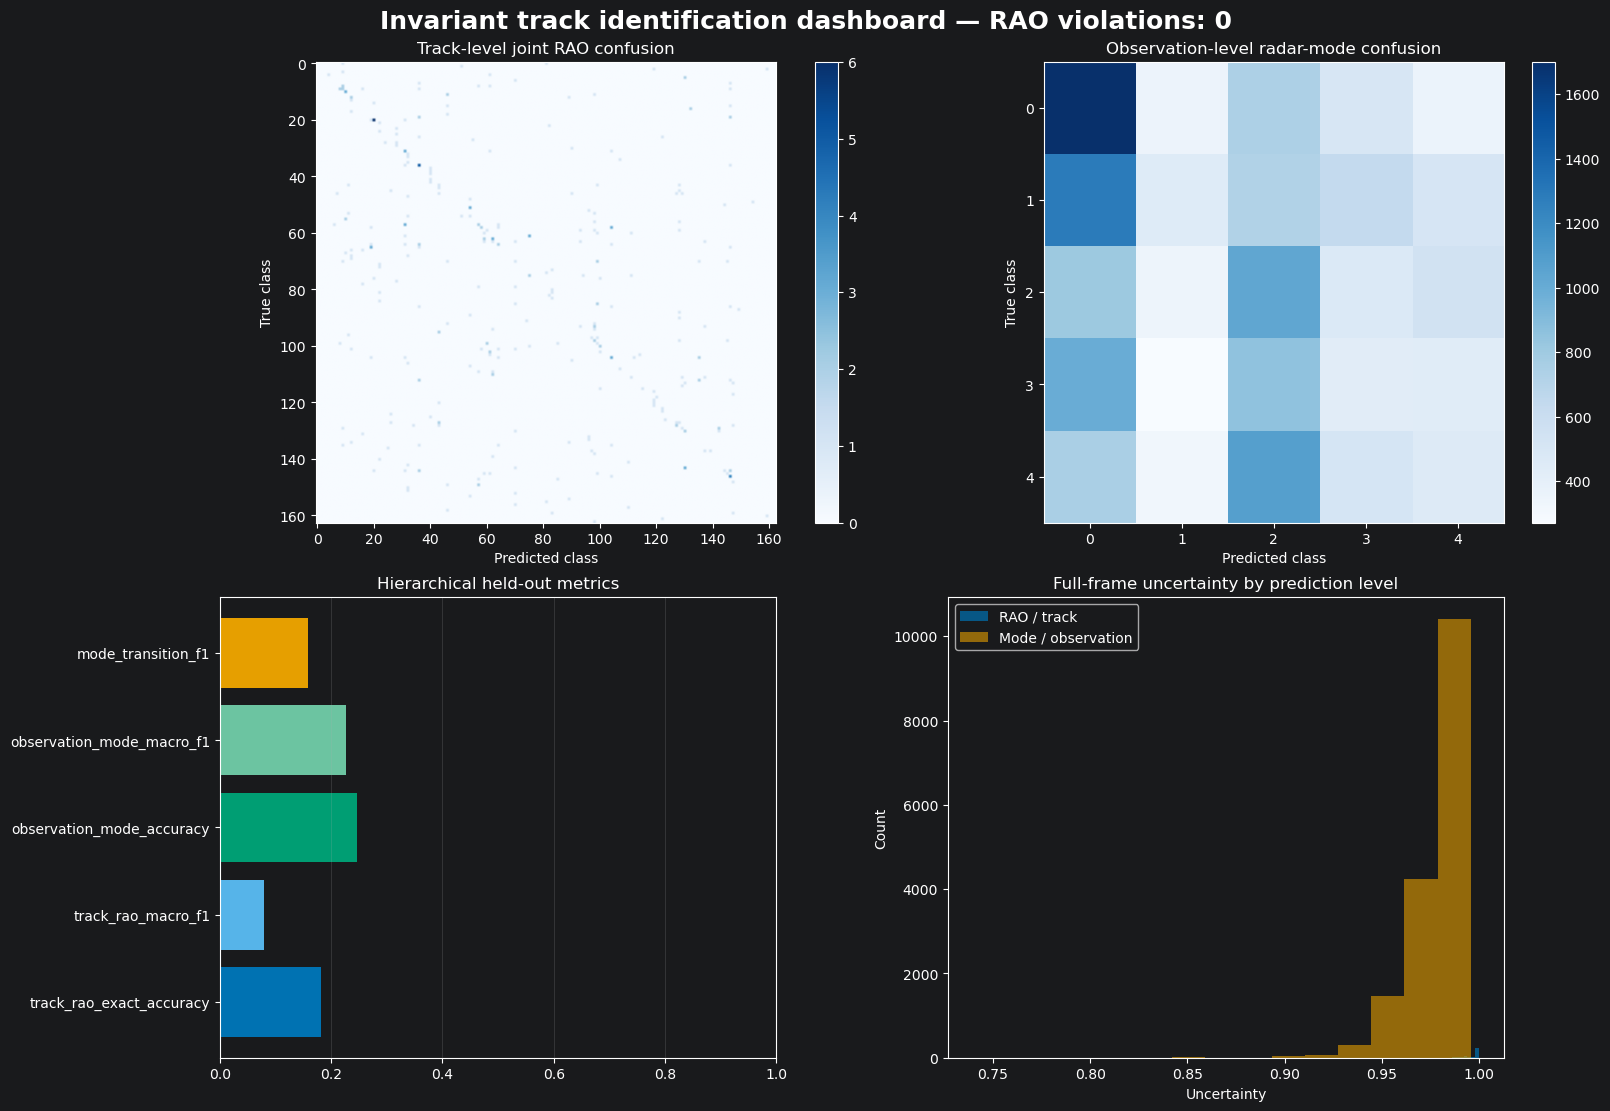

C:\Users\theon\r-GCN_fusion\artifacts\Track_identification\track_identification_dashboard.png


In [28]:
# Static dashboard: track RAO and observation-mode performance remain visibly separate.
rao_cm = confusion_matrix(rao_truth, rao_predicted, labels=np.unique(np.concatenate((rao_truth, rao_predicted))))
mode_cm = confusion_matrix(mode_truth, mode_predicted, labels=np.unique(np.concatenate((mode_truth, mode_predicted))))
fig, axes = plt.subplots(2, 2, figsize=(16, 11), constrained_layout=True)
for axis, matrix, title in ((axes[0, 0], rao_cm, "Track-level joint RAO confusion"), (axes[0, 1], mode_cm, "Observation-level radar-mode confusion")):
    image = axis.imshow(matrix, cmap="Blues")
    axis.set(title=title, xlabel="Predicted class", ylabel="True class")
    fig.colorbar(image, ax=axis, fraction=.046)
metric_names = ["track_rao_exact_accuracy", "track_rao_macro_f1", "observation_mode_accuracy", "observation_mode_macro_f1", "mode_transition_f1"]
axes[1, 0].barh(metric_names, [dashboard_metrics[name] for name in metric_names], color=["#0072B2", "#56B4E9", "#009E73", "#6CC4A1", "#E69F00"])
axes[1, 0].set(xlim=(0, 1), title="Hierarchical held-out metrics")
axes[1, 0].grid(axis="x", alpha=.25)
rao_uncertainty = final_outputs["evidential"]["track_rao"]["uncertainty"][test_track_indices].detach().cpu().numpy().ravel()
mode_uncertainty = final_outputs["evidential"]["radar_mode"]["uncertainty"][test_observation_positions].detach().cpu().numpy().ravel()
axes[1, 1].hist(rao_uncertainty, bins=15, alpha=.7, label="RAO / track", color="#0072B2")
axes[1, 1].hist(mode_uncertainty, bins=15, alpha=.6, label="Mode / observation", color="#E69F00")
axes[1, 1].set(title="Full-frame uncertainty by prediction level", xlabel="Uncertainty", ylabel="Count")
axes[1, 1].legend()
fig.suptitle(f"Invariant track identification dashboard — RAO violations: {RAO_VIOLATION_COUNT}", fontsize=18, fontweight="bold")
dashboard_path = ARTIFACT_DIR / "track_identification_dashboard.png"
fig.savefig(dashboard_path, dpi=200, bbox_inches="tight")
plt.show()
print(dashboard_path)


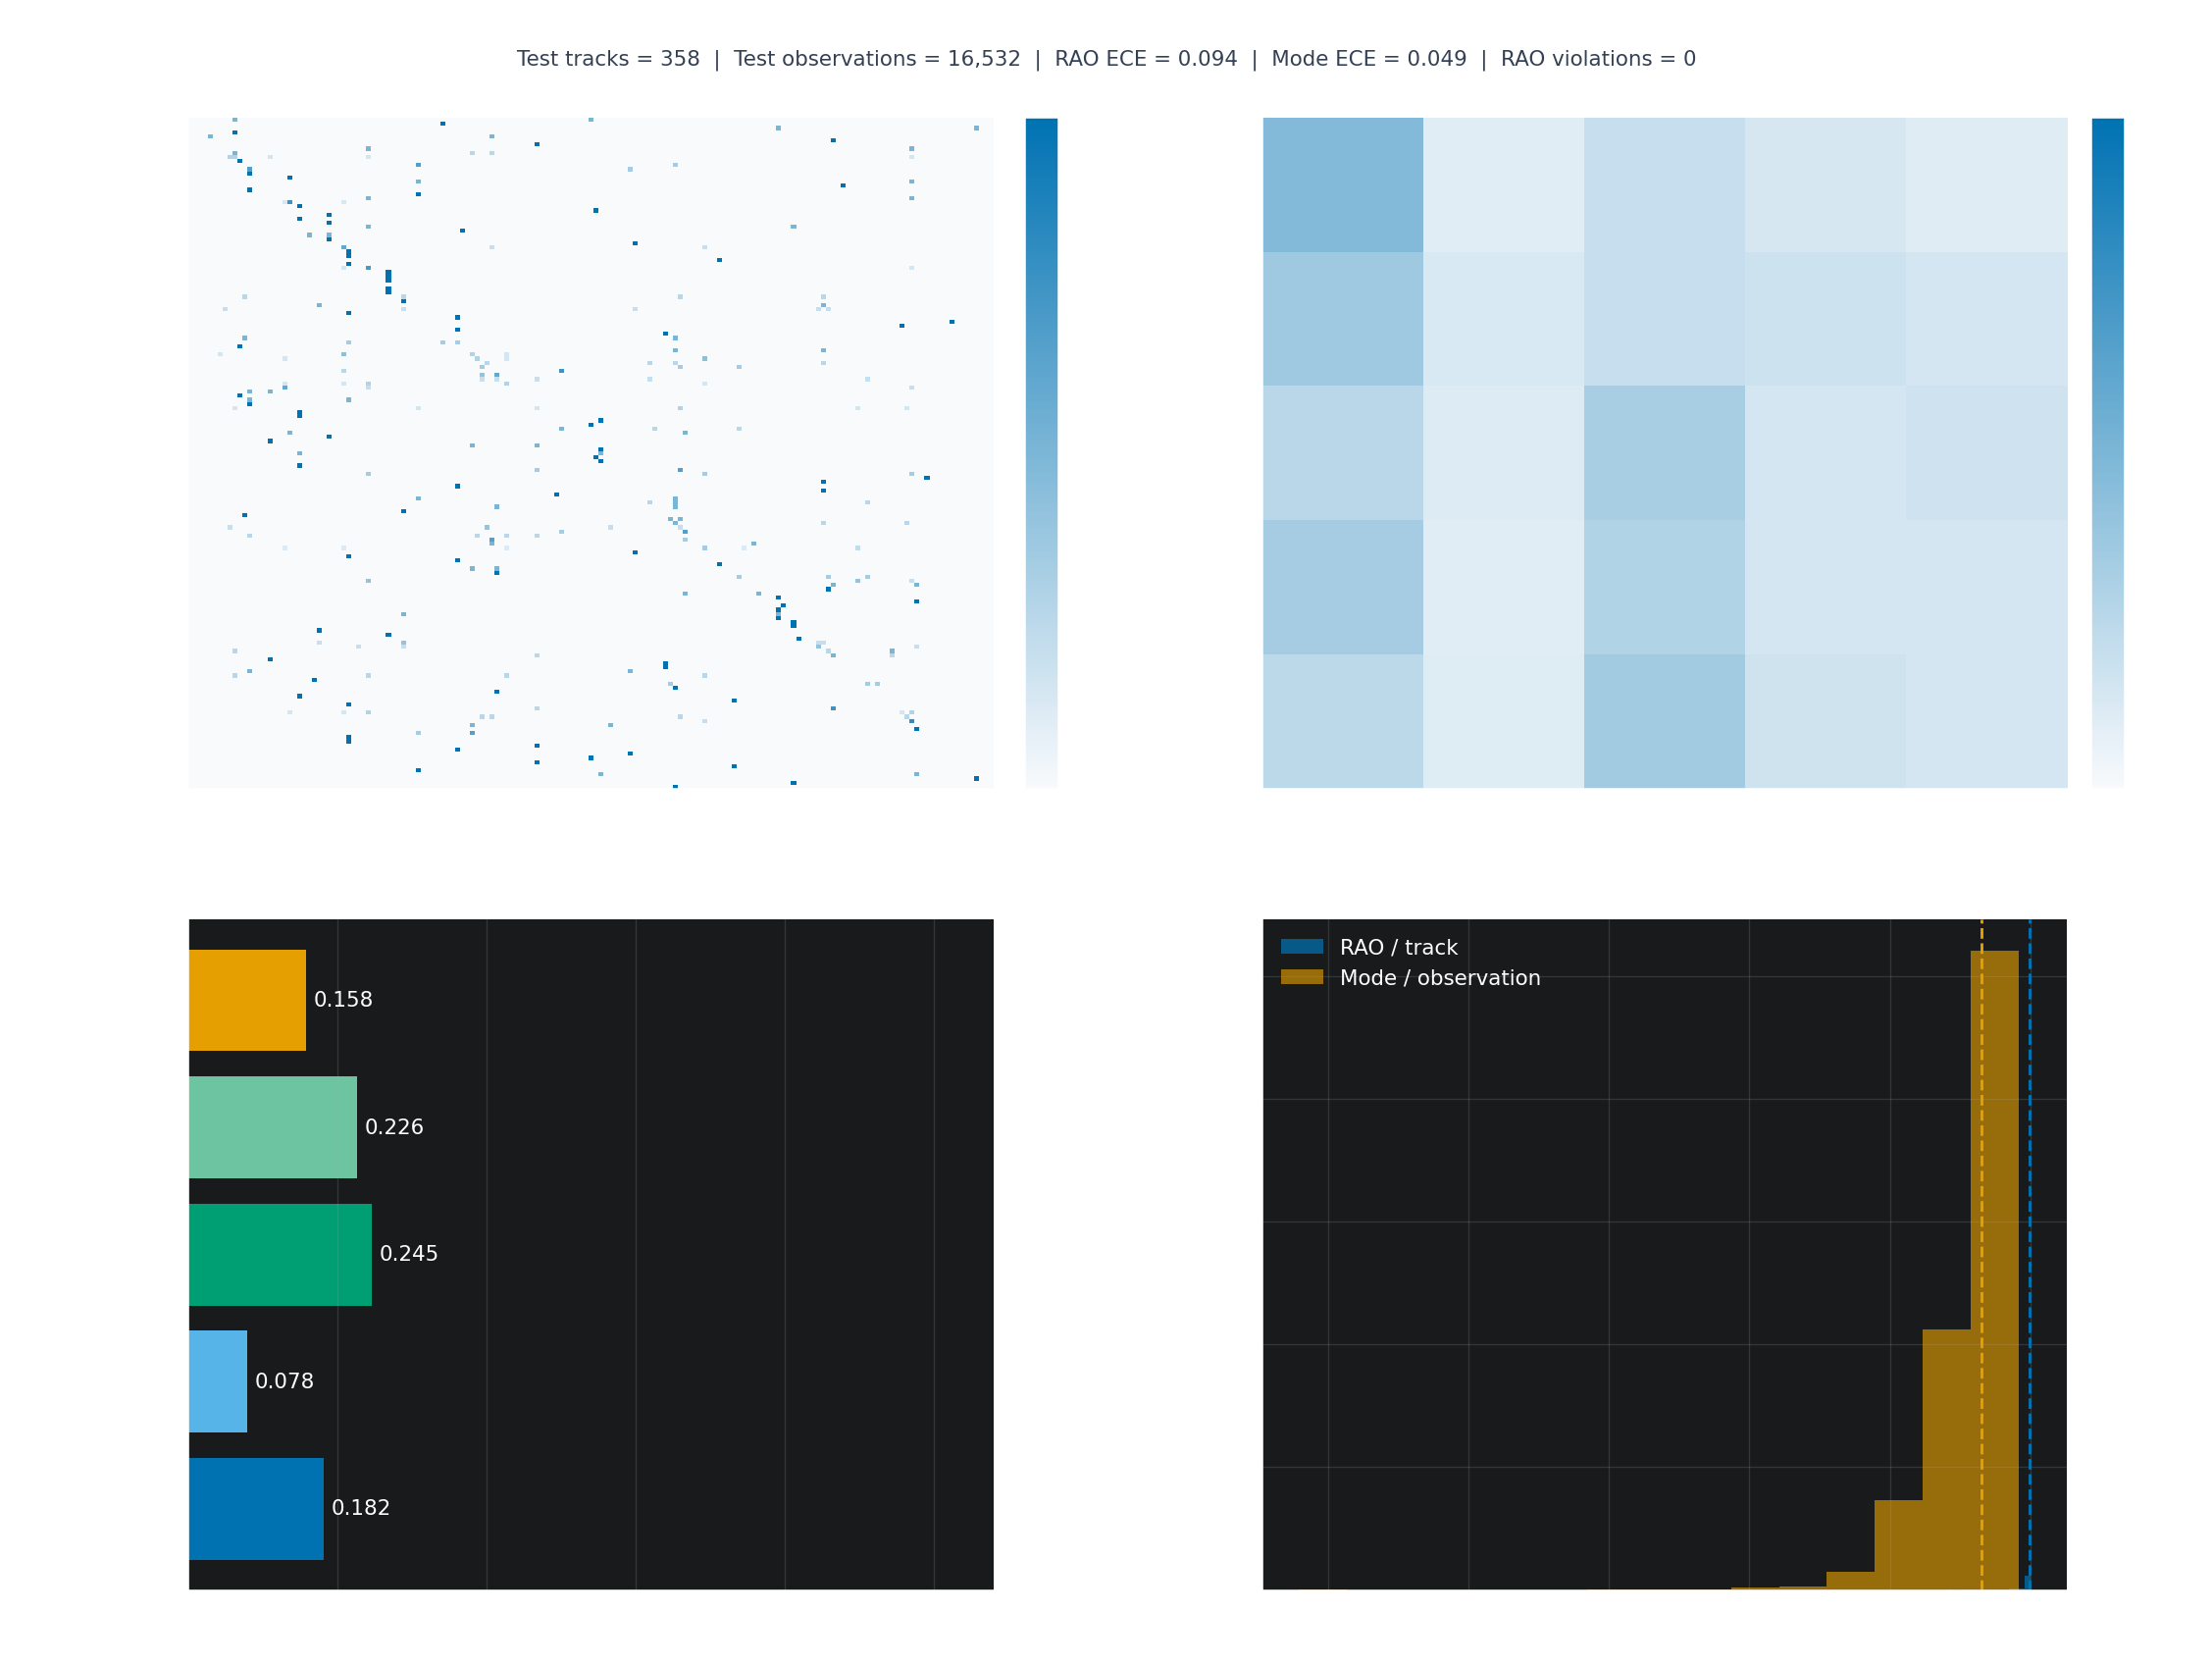

Publication dashboard exports:
  C:\Users\theon\r-GCN_fusion\artifacts\Track_identification\track_identification_dashboard_publication.png
  C:\Users\theon\r-GCN_fusion\artifacts\Track_identification\track_identification_dashboard_publication.pdf
  C:\Users\theon\r-GCN_fusion\artifacts\Track_identification\track_identification_dashboard_publication.svg


In [29]:
# Publication-grade rendering of the hierarchical dashboard computed above.
# Deterministic PNG/PDF/SVG exports mirror the publication workflow used by the
# advanced joint-world notebook while preserving the two prediction levels.
from matplotlib.colors import LinearSegmentedColormap

PUBLICATION_DPI = 300
PUBLICATION_FORMATS = ("png", "pdf", "svg")
PUBLICATION_PALETTE = {
    "blue": "#0072B2", "light_blue": "#56B4E9", "green": "#009E73",
    "light_green": "#6CC4A1", "orange": "#E69F00", "grey": "#667085",
}


def _row_normalise(matrix: np.ndarray) -> np.ndarray:
    totals = matrix.sum(axis=1, keepdims=True)
    return np.divide(matrix, totals, out=np.zeros_like(matrix, dtype=float), where=totals != 0)


publication_rc = {
    "figure.dpi": 140, "savefig.dpi": PUBLICATION_DPI,
    "font.family": "sans-serif", "font.size": 11,
    "axes.titlesize": 14, "axes.titleweight": "bold", "axes.labelsize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": 0.8, "grid.alpha": 0.18, "grid.linewidth": 0.7,
    "legend.frameon": False, "svg.fonttype": "none", "pdf.fonttype": 42,
}
metric_names = (
    "track_rao_exact_accuracy", "track_rao_macro_f1",
    "observation_mode_accuracy", "observation_mode_macro_f1", "mode_transition_f1",
)
metric_labels = ("RAO accuracy", "RAO macro F1", "Mode accuracy", "Mode macro F1", "Transition F1")
metric_colours = (
    PUBLICATION_PALETTE["blue"], PUBLICATION_PALETTE["light_blue"],
    PUBLICATION_PALETTE["green"], PUBLICATION_PALETTE["light_green"], PUBLICATION_PALETTE["orange"],
)

with plt.rc_context(publication_rc):
    publication_figure, publication_axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
    publication_figure.patch.set_facecolor("white")
    blue_map = LinearSegmentedColormap.from_list("hierarchical_blue", ["#F8FAFC", PUBLICATION_PALETTE["blue"]])
    for axis, matrix, xlabel, ylabel in (
        (publication_axes[0, 0], rao_cm, "Predicted joint RAO class", "True joint RAO class"),
        (publication_axes[0, 1], mode_cm, "Predicted radar-mode class", "True radar-mode class"),
    ):
        rates = _row_normalise(matrix)
        image = axis.imshow(rates, cmap=blue_map, vmin=0, vmax=1, aspect="auto", interpolation="nearest")
        colour_bar = publication_figure.colorbar(image, ax=axis, fraction=0.046, pad=0.03)
        colour_bar.set_label("Row-normalised rate")
        axis.set(xlabel=xlabel, ylabel=ylabel)
        if matrix.shape[0] <= 20 and matrix.shape[1] <= 20:
            axis.set_xticks(np.arange(matrix.shape[1]))
            axis.set_yticks(np.arange(matrix.shape[0]))

    values = [dashboard_metrics[name] for name in metric_names]
    bars = publication_axes[1, 0].barh(metric_labels, values, color=metric_colours)
    publication_axes[1, 0].bar_label(bars, labels=[f"{value:.3f}" for value in values], padding=4)
    publication_axes[1, 0].set(xlabel="Score", xlim=(0, 1.08))
    publication_axes[1, 0].grid(True, axis="x")

    publication_axes[1, 1].hist(rao_uncertainty, bins=15, alpha=.72, label="RAO / track", color=PUBLICATION_PALETTE["blue"])
    publication_axes[1, 1].hist(mode_uncertainty, bins=15, alpha=.62, label="Mode / observation", color=PUBLICATION_PALETTE["orange"])
    publication_axes[1, 1].axvline(np.median(rao_uncertainty), color=PUBLICATION_PALETTE["blue"], linestyle="--", linewidth=1.5)
    publication_axes[1, 1].axvline(np.median(mode_uncertainty), color=PUBLICATION_PALETTE["orange"], linestyle="--", linewidth=1.5)
    publication_axes[1, 1].set(xlabel="Full-frame uncertainty", ylabel="Samples")
    publication_axes[1, 1].legend(loc="best")
    publication_axes[1, 1].grid(True)

    panel_titles = ("Track-level joint RAO confusion", "Observation-level radar-mode confusion", "Held-out performance", "Uncertainty by prediction level")
    for panel_index, (axis, title) in enumerate(zip(publication_axes.ravel(), panel_titles)):
        axis.set_title(title, loc="left", pad=12)
        axis.text(-0.10, 1.08, chr(65 + panel_index), transform=axis.transAxes, fontsize=16, fontweight="bold", va="top")

    subtitle = (
        f"Test tracks = {len(test_track_indices):,}  |  Test observations = {len(test_observation_positions):,}  |  "
        f"RAO ECE = {dashboard_metrics['track_rao_ece']:.3f}  |  "
        f"Mode ECE = {dashboard_metrics['observation_mode_ece']:.3f}  |  RAO violations = {RAO_VIOLATION_COUNT}"
    )
    publication_figure.suptitle("Invariant track-identification evaluation", fontsize=21, fontweight="bold")
    publication_figure.text(0.5, 0.975, subtitle, ha="center", va="top", fontsize=11, color="#344054")

    publication_paths = []
    for suffix in PUBLICATION_FORMATS:
        output_path = ARTIFACT_DIR / f"track_identification_dashboard_publication.{suffix}"
        save_options = {"bbox_inches": "tight", "facecolor": "white"}
        if suffix == "png":
            save_options["dpi"] = PUBLICATION_DPI
        publication_figure.savefig(output_path, **save_options)
        publication_paths.append(output_path)
    plt.show()

print("Publication dashboard exports:")
for output_path in publication_paths:
    print(f"  {output_path}")


In [30]:
# Interactive Plotly companion to the publication-grade hierarchical dashboard.
# HTML is self-contained; optional static export requires Kaleido (`pip install kaleido`).
import plotly.graph_objects as go
from plotly.subplots import make_subplots

PLOTLY_STATIC_EXPORT = False
PLOTLY_PALETTE = {"rao": "#0072B2", "mode": "#009E73", "transition": "#E69F00", "neutral": "#667085"}


def _reliability_points(probabilities: np.ndarray, truth: np.ndarray, bins: int = 10):
    confidence = probabilities.max(1)
    predicted = probabilities.argmax(1)
    edges = np.linspace(0, 1, bins + 1)
    rows = []
    for lower, upper in zip(edges[:-1], edges[1:]):
        selected = (confidence > lower) & (confidence <= upper)
        if selected.any():
            rows.append((confidence[selected].mean(), (predicted[selected] == truth[selected]).mean(), selected.sum()))
    return tuple(np.asarray(items) for items in zip(*rows)) if rows else (np.array([]), np.array([]), np.array([]))


rao_reliability_x, rao_reliability_y, rao_reliability_count = _reliability_points(
    rao_probabilities[test_track_indices], rao_truth
)
mode_reliability_x, mode_reliability_y, mode_reliability_count = _reliability_points(
    mode_probabilities[test_observation_positions], mode_truth
)
interactive_figure = make_subplots(
    rows=2, cols=3,
    subplot_titles=(
        "<b>A</b> Track-level joint RAO confusion", "<b>B</b> Observation-level mode confusion", "<b>C</b> Held-out performance",
        "<b>D</b> Reliability", "<b>E</b> Uncertainty by prediction level", "<b>F</b> Uncertainty by outcome",
    ),
    horizontal_spacing=.09, vertical_spacing=.17,
)
for matrix, row_rates, position in ((rao_cm, _row_normalise(rao_cm), (1, 1)), (mode_cm, _row_normalise(mode_cm), (1, 2))):
    interactive_figure.add_trace(go.Heatmap(
        z=row_rates, customdata=matrix, colorscale=[[0, "#F8FAFC"], [1, PLOTLY_PALETTE["rao"]]], zmin=0, zmax=1,
        colorbar={"title": "Row rate", "len": .34},
        hovertemplate="True class %{y}<br>Predicted class %{x}<br>Count %{customdata}<br>Row rate %{z:.3f}<extra></extra>",
        showscale=position == (1, 2),
    ), row=position[0], col=position[1])

metric_values = [dashboard_metrics[name] for name in metric_names]
interactive_figure.add_trace(go.Bar(
    x=metric_values, y=metric_labels, orientation="h", text=[f"{value:.3f}" for value in metric_values], textposition="outside",
    marker_color=list(metric_colours), hovertemplate="%{y}<br>Score %{x:.3f}<extra></extra>", showlegend=False,
), row=1, col=3)

interactive_figure.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1], mode="lines", name="Perfect calibration", line={"color": PLOTLY_PALETTE["neutral"], "dash": "dash"}, hoverinfo="skip",
), row=2, col=1)
for x_values, y_values, counts, name, colour in (
    (rao_reliability_x, rao_reliability_y, rao_reliability_count, "RAO / track", PLOTLY_PALETTE["rao"]),
    (mode_reliability_x, mode_reliability_y, mode_reliability_count, "Mode / observation", PLOTLY_PALETTE["mode"]),
):
    interactive_figure.add_trace(go.Scatter(
        x=x_values, y=y_values, mode="lines+markers", name=name, customdata=counts,
        marker={"size": 7 + 2 * np.sqrt(counts), "color": colour, "line": {"color": "white", "width": 1}}, line={"color": colour, "width": 3},
        hovertemplate="Confidence %{x:.3f}<br>Accuracy %{y:.3f}<br>Samples %{customdata}<extra></extra>",
    ), row=2, col=1)

interactive_figure.add_trace(go.Histogram(x=rao_uncertainty, nbinsx=15, name="RAO / track", marker_color=PLOTLY_PALETTE["rao"], opacity=.72), row=2, col=2)
interactive_figure.add_trace(go.Histogram(x=mode_uncertainty, nbinsx=15, name="Mode / observation", marker_color=PLOTLY_PALETTE["transition"], opacity=.62), row=2, col=2)
rao_correct = rao_predicted == rao_truth
mode_correct = mode_predicted == mode_truth
for values, label, colour in (
    (rao_uncertainty[rao_correct], "RAO correct", PLOTLY_PALETTE["rao"]),
    (rao_uncertainty[~rao_correct], "RAO incorrect", PLOTLY_PALETTE["transition"]),
    (mode_uncertainty[mode_correct], "Mode correct", PLOTLY_PALETTE["mode"]),
    (mode_uncertainty[~mode_correct], "Mode incorrect", "#CC79A7"),
):
    if values.size:
        interactive_figure.add_trace(go.Box(y=values, name=label, boxmean=True, marker_color=colour, showlegend=False), row=2, col=3)

interactive_figure.update_xaxes(title_text="Predicted class", row=1, col=1)
interactive_figure.update_yaxes(title_text="True class", autorange="reversed", row=1, col=1)
interactive_figure.update_xaxes(title_text="Predicted class", row=1, col=2)
interactive_figure.update_yaxes(title_text="True class", autorange="reversed", row=1, col=2)
interactive_figure.update_xaxes(title_text="Score", range=[0, 1.08], row=1, col=3)
interactive_figure.update_xaxes(title_text="Mean confidence", range=[0, 1], row=2, col=1)
interactive_figure.update_yaxes(title_text="Observed accuracy", range=[0, 1], row=2, col=1)
interactive_figure.update_xaxes(title_text="Full-frame uncertainty", row=2, col=2)
interactive_figure.update_yaxes(title_text="Samples", row=2, col=2)
interactive_figure.update_yaxes(title_text="Full-frame uncertainty", row=2, col=3)
interactive_figure.update_layout(
    template="plotly_white", height=1050, width=1700, barmode="overlay",
    title={"text": "<b>Interactive invariant track-identification evaluation</b>", "x": .5, "xanchor": "center", "font": {"size": 25}},
    margin={"l": 80, "r": 80, "t": 125, "b": 70}, hovermode="closest",
    legend={"orientation": "h", "yanchor": "bottom", "y": 1.03, "xanchor": "right", "x": 1},
)
interactive_figure.update_xaxes(showgrid=True, gridcolor="rgba(102,112,133,.15)", zeroline=False)
interactive_figure.update_yaxes(showgrid=True, gridcolor="rgba(102,112,133,.15)", zeroline=False)
interactive_path = ARTIFACT_DIR / "track_identification_dashboard_interactive.html"
interactive_figure.write_html(interactive_path, include_plotlyjs=True, full_html=True)
if PLOTLY_STATIC_EXPORT:
    interactive_figure.write_image(ARTIFACT_DIR / "track_identification_dashboard_plotly.svg")
    interactive_figure.write_image(ARTIFACT_DIR / "track_identification_dashboard_plotly.png", width=1700, height=1050, scale=2)
interactive_figure.show(config={"displaylogo": False, "responsive": True, "toImageButtonOptions": {"format": "svg"}})
print(f"Interactive dashboard: {interactive_path}")


Interactive dashboard: C:\Users\theon\r-GCN_fusion\artifacts\Track_identification\track_identification_dashboard_interactive.html


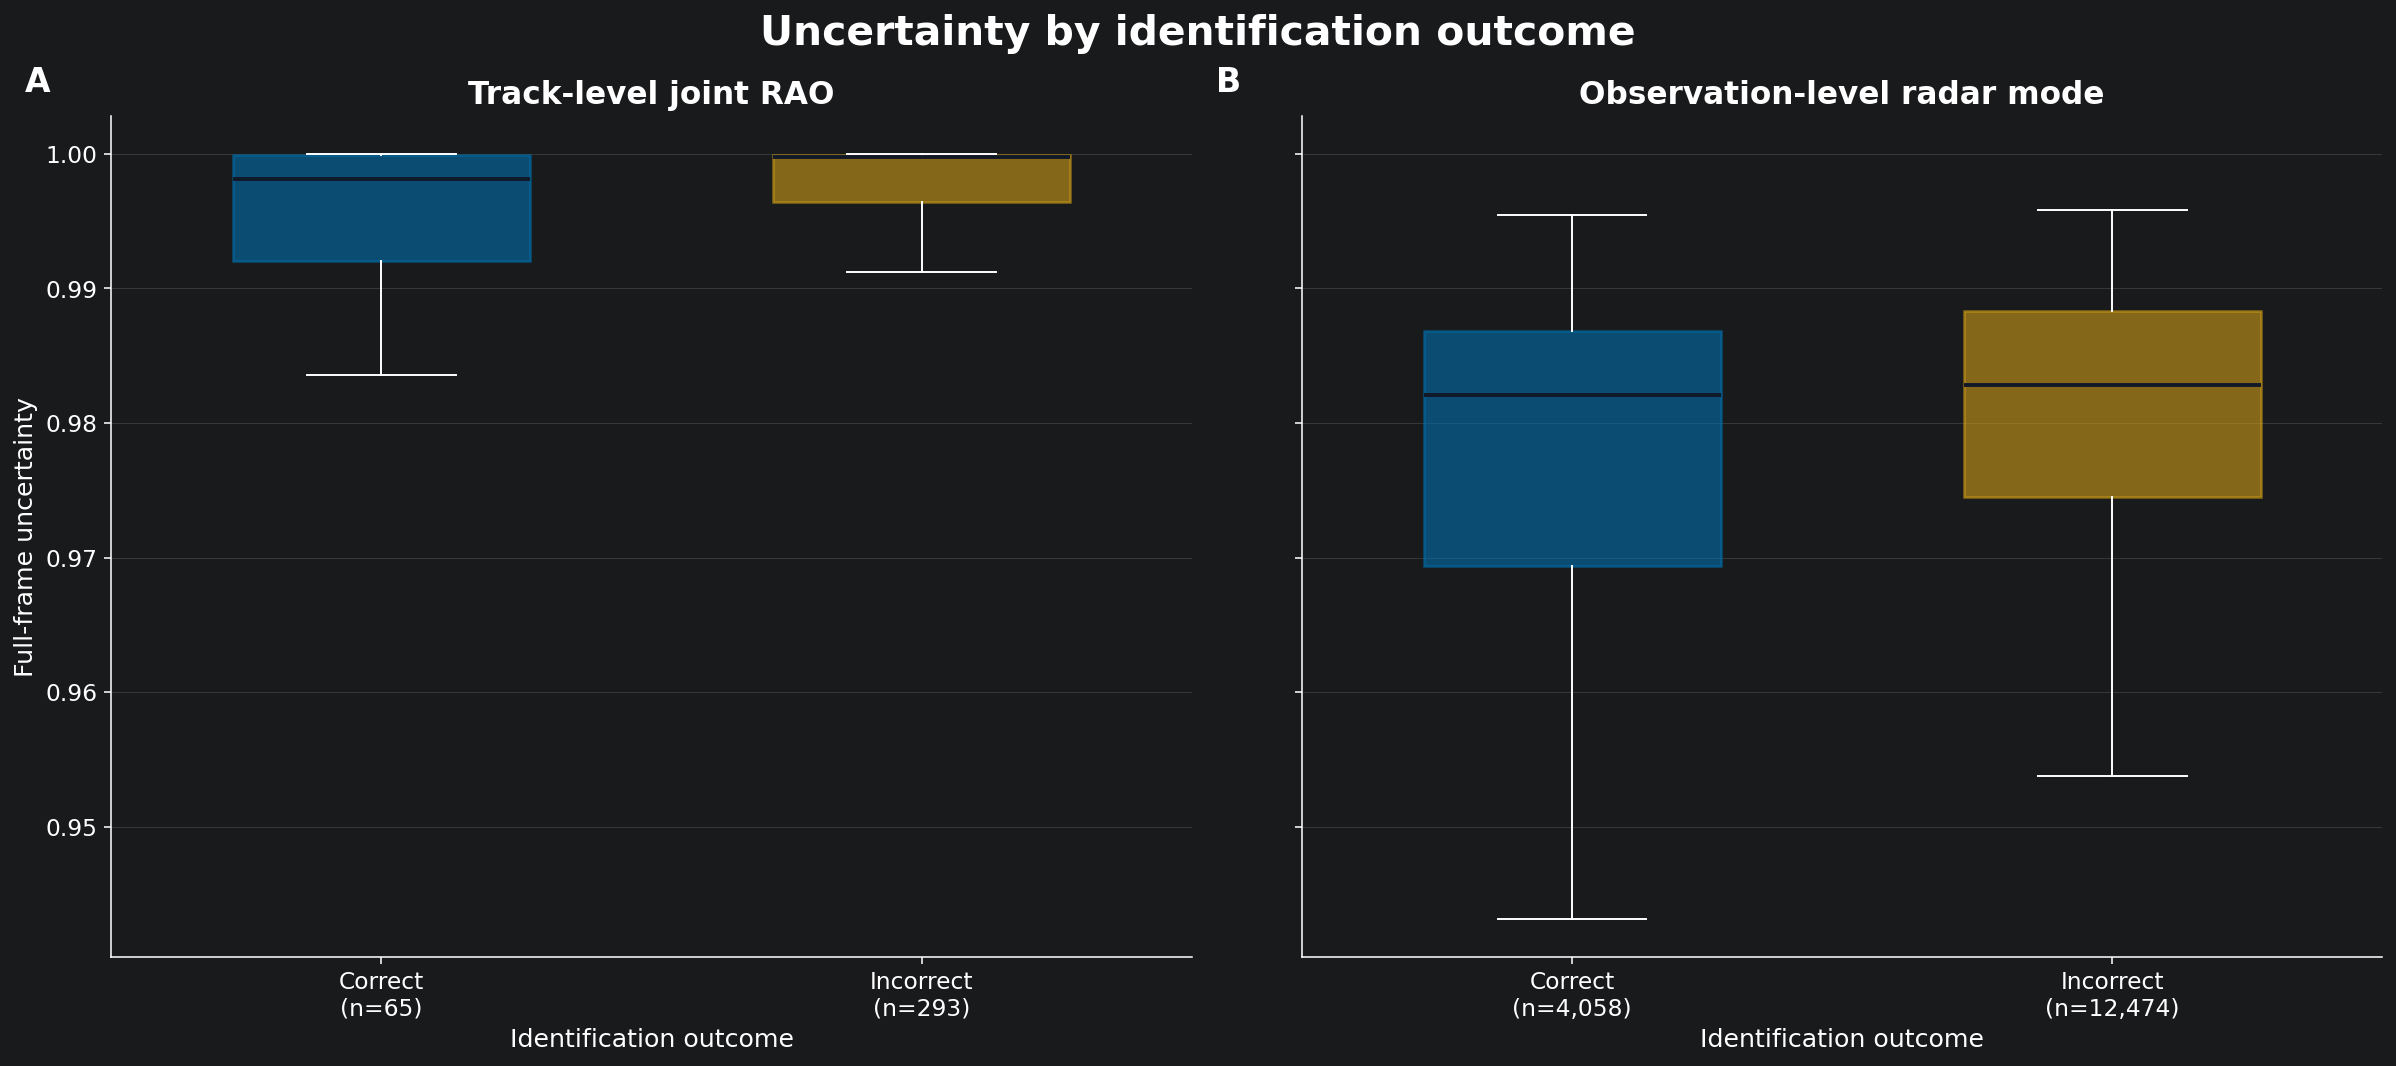

Outcome-specific uncertainty exports:
  C:\Users\theon\r-GCN_fusion\artifacts\Track_identification\track_identification_uncertainty_by_outcome.png
  C:\Users\theon\r-GCN_fusion\artifacts\Track_identification\track_identification_uncertainty_by_outcome.pdf
  C:\Users\theon\r-GCN_fusion\artifacts\Track_identification\track_identification_uncertainty_by_outcome.svg


In [31]:
# Publication-ready uncertainty views for correct and incorrect predictions at each hierarchy level.
OUTCOME_COLOURS = {"correct": "#0072B2", "incorrect": "#D4A017"}
OUTCOME_DPI = 300
outcome_groups = (
    (rao_uncertainty[rao_correct], rao_uncertainty[~rao_correct], "Track-level joint RAO"),
    (mode_uncertainty[mode_correct], mode_uncertainty[~mode_correct], "Observation-level radar mode"),
)
outcome_rc = {
    "figure.dpi": 140, "savefig.dpi": OUTCOME_DPI, "font.family": "sans-serif", "font.size": 12,
    "axes.titlesize": 16, "axes.titleweight": "bold", "axes.labelsize": 13,
    "axes.spines.top": False, "axes.spines.right": False, "grid.alpha": .20,
    "svg.fonttype": "none", "pdf.fonttype": 42,
}
with plt.rc_context(outcome_rc):
    outcome_figure, outcome_axes = plt.subplots(1, 2, figsize=(17, 7.5), sharey=True, constrained_layout=True)
    for panel_index, (axis, (correct_values, incorrect_values, title)) in enumerate(zip(outcome_axes, outcome_groups)):
        populated = [(correct_values, "Correct", OUTCOME_COLOURS["correct"]), (incorrect_values, "Incorrect", OUTCOME_COLOURS["incorrect"])]
        populated = [item for item in populated if item[0].size]
        if populated:
            boxes = axis.boxplot(
                [item[0] for item in populated], tick_labels=[f"{item[1]}\n(n={item[0].size:,})" for item in populated],
                patch_artist=True, showfliers=False, widths=.55,
                medianprops={"color": "#111827", "linewidth": 2},
            )
            for patch, (_, _, colour) in zip(boxes["boxes"], populated):
                patch.set(facecolor=colour, edgecolor=colour, alpha=.58, linewidth=1.3)
        else:
            axis.text(.5, .5, "No held-out samples", ha="center", va="center", transform=axis.transAxes)
        axis.set(title=title, xlabel="Identification outcome")
        axis.grid(True, axis="y")
        axis.text(-.08, 1.06, chr(65 + panel_index), transform=axis.transAxes, fontsize=17, fontweight="bold", va="top")
    outcome_axes[0].set_ylabel("Full-frame uncertainty")
    outcome_figure.suptitle("Uncertainty by identification outcome", fontsize=21, fontweight="bold")
    outcome_paths = []
    for suffix in ("png", "pdf", "svg"):
        output_path = ARTIFACT_DIR / f"track_identification_uncertainty_by_outcome.{suffix}"
        save_options = {"bbox_inches": "tight", "facecolor": "white"}
        if suffix == "png":
            save_options["dpi"] = OUTCOME_DPI
        outcome_figure.savefig(output_path, **save_options)
        outcome_paths.append(output_path)
    plt.show()
print("Outcome-specific uncertainty exports:")
for output_path in outcome_paths:
    print(f"  {output_path}")


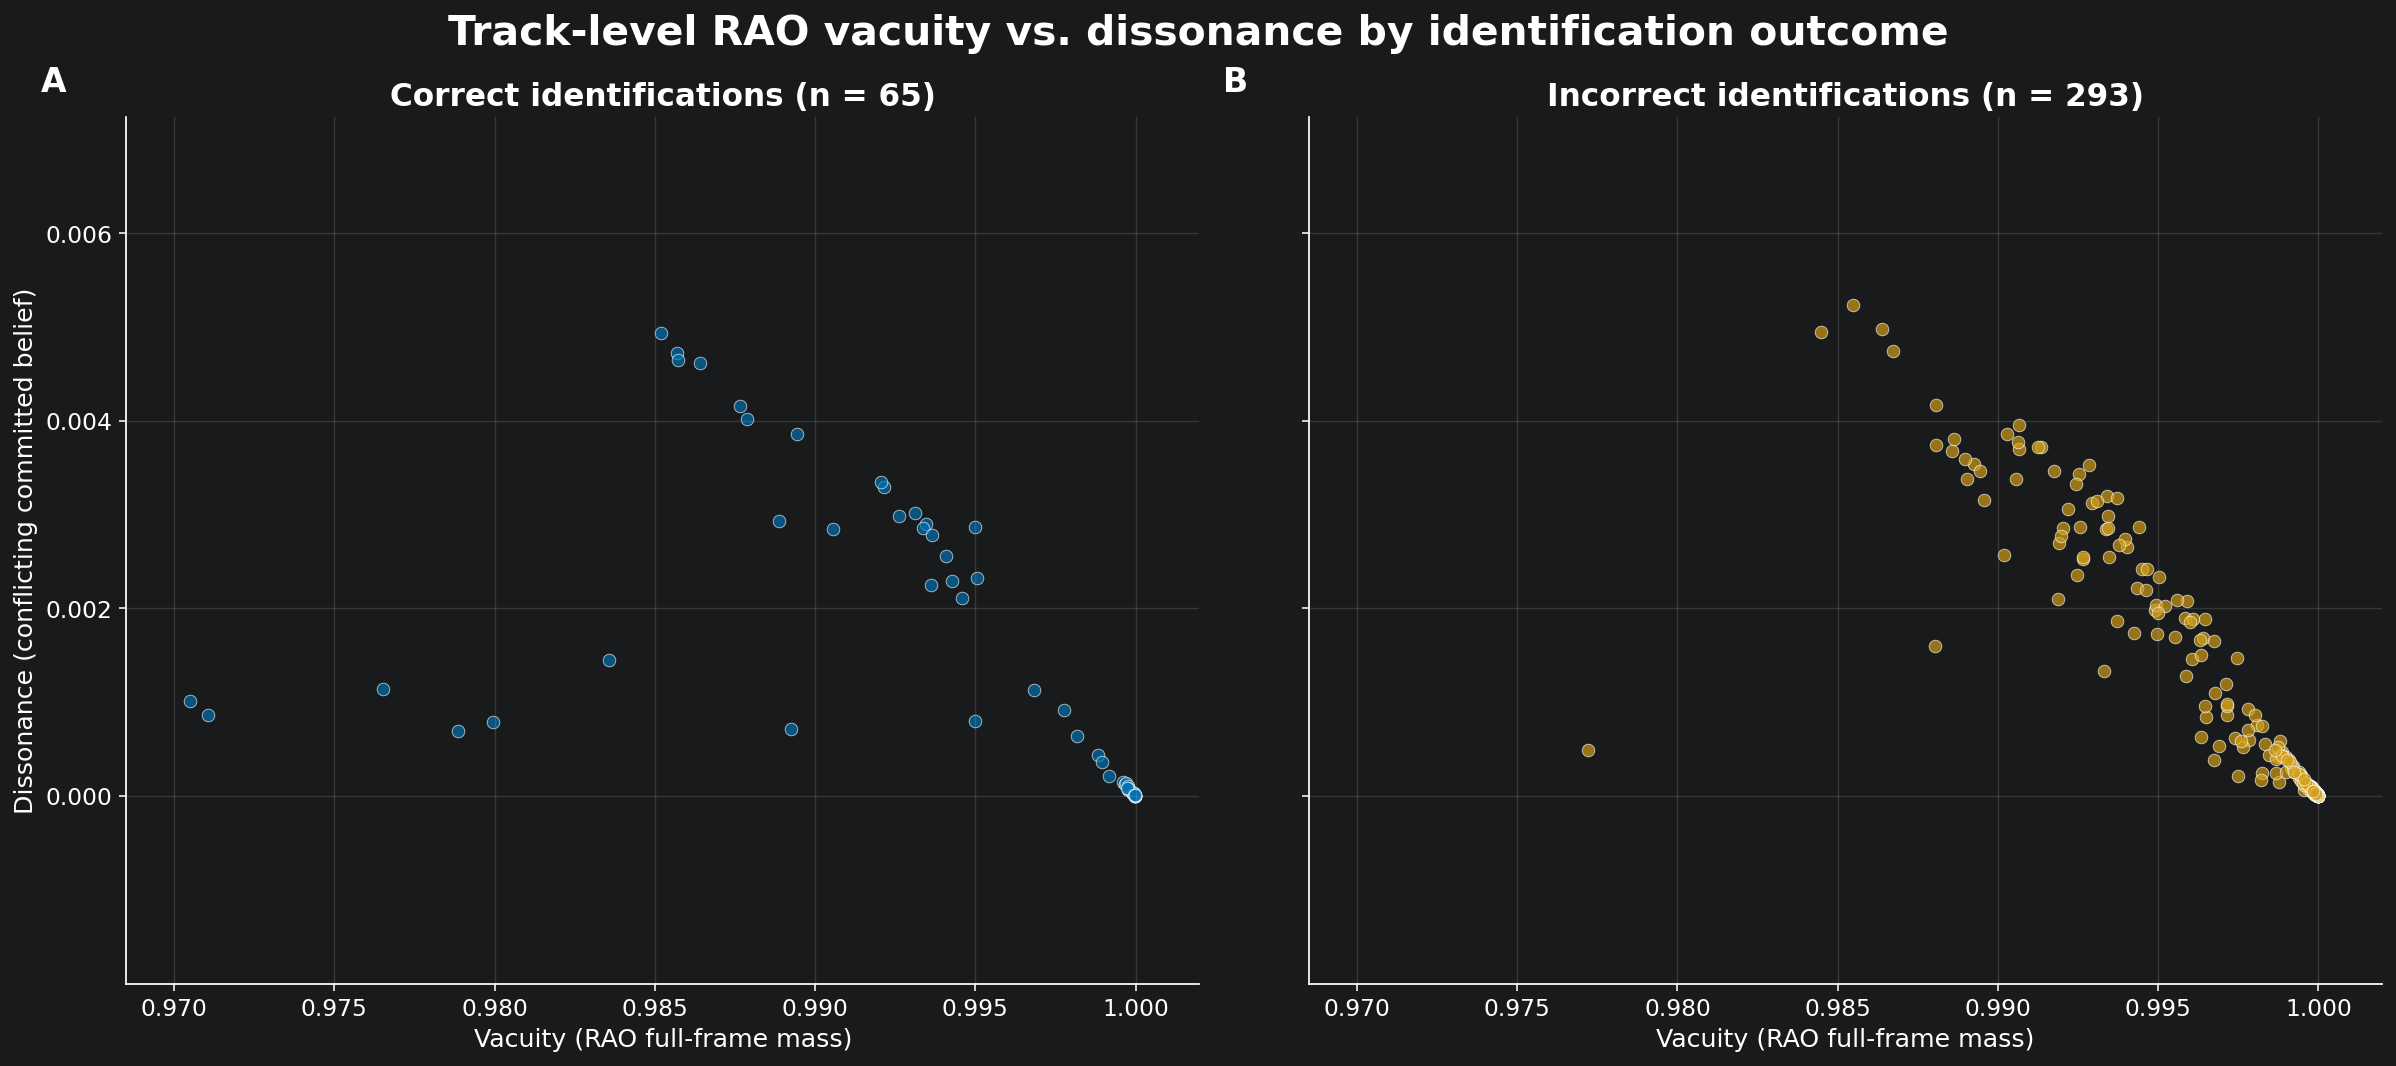

Track-level RAO vacuity–dissonance exports:
  C:\Users\theon\r-GCN_fusion\artifacts\Track_identification\track_rao_vacuity_vs_dissonance_by_outcome.png
  C:\Users\theon\r-GCN_fusion\artifacts\Track_identification\track_rao_vacuity_vs_dissonance_by_outcome.pdf
  C:\Users\theon\r-GCN_fusion\artifacts\Track_identification\track_rao_vacuity_vs_dissonance_by_outcome.svg


In [32]:
# Publication-ready pair: track-level RAO vacuity–dissonance views for correct and incorrect identifications.
# For the Dirichlet opinion, uncertainty is the full-frame mass (vacuity), while
# dissonance measures conflict among the singleton belief masses.
VACUITY_DISSONANCE_COLOURS = {"correct": "#0072B2", "incorrect": "#D4A017"}
VACUITY_DISSONANCE_DPI = 300


def _singleton_dissonance(belief: np.ndarray) -> np.ndarray:
    """Calculate Subjective-Logic dissonance for rows of singleton beliefs."""
    belief = np.asarray(belief, dtype=np.float64)
    if belief.ndim != 2:
        raise ValueError("belief must have shape (samples, classes)")
    dissonance = np.zeros(belief.shape[0], dtype=np.float64)
    for class_index in range(belief.shape[1]):
        focal_belief = belief[:, class_index]
        others = np.delete(belief, class_index, axis=1)
        other_total = others.sum(axis=1)
        balance = np.divide(
            2.0 * np.minimum(focal_belief[:, None], others),
            focal_belief[:, None] + others,
            out=np.zeros_like(others),
            where=(focal_belief[:, None] + others) > 0.0,
        )
        conflict = np.divide(
            (others * balance).sum(axis=1),
            other_total,
            out=np.zeros_like(other_total),
            where=other_total > 0.0,
        )
        dissonance += focal_belief * conflict
    return dissonance


def _padded_limits(values: np.ndarray, minimum_span: float = 0.05) -> tuple[float, float]:
    """Return shared plot limits with enough padding to avoid clipped points."""
    lower, upper = float(np.min(values)), float(np.max(values))
    span = max(upper - lower, minimum_span)
    return lower - 0.04 * span, upper + 0.04 * span


rao_correct = rao_predicted == rao_truth
rao_vacuity = (
    final_outputs["evidential"]["track_rao"]["uncertainty"][test_track_indices]
    .detach().float().cpu().numpy().ravel()
)
rao_belief = (
    final_outputs["evidential"]["track_rao"]["belief"][test_track_indices]
    .detach().float().cpu().numpy()
)
rao_dissonance = _singleton_dissonance(rao_belief)

vacuity_limits = _padded_limits(rao_vacuity)
dissonance_limits = _padded_limits(rao_dissonance)
identification_groups = (
    (rao_correct, "Correct identifications", VACUITY_DISSONANCE_COLOURS["correct"]),
    (~rao_correct, "Incorrect identifications", VACUITY_DISSONANCE_COLOURS["incorrect"]),
)
pair_rc = {
    "figure.dpi": 140, "savefig.dpi": VACUITY_DISSONANCE_DPI,
    "font.family": "sans-serif", "font.size": 12,
    "axes.titlesize": 16, "axes.titleweight": "bold", "axes.labelsize": 13,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": 0.9, "grid.alpha": 0.20, "grid.linewidth": 0.7,
    "svg.fonttype": "none", "pdf.fonttype": 42,
}

with plt.rc_context(pair_rc):
    vacuity_dissonance_figure, vacuity_dissonance_axes = plt.subplots(
        1, 2, figsize=(17, 7.5), sharex=True, sharey=True, constrained_layout=True
    )
    for panel_index, (axis, (selected, title, colour)) in enumerate(
        zip(vacuity_dissonance_axes, identification_groups)
    ):
        group_size = int(np.count_nonzero(selected))
        if group_size:
            axis.scatter(
                rao_vacuity[selected], rao_dissonance[selected],
                s=42, c=colour, alpha=0.68, edgecolors="white",
                linewidths=0.45, rasterized=True,
            )
        else:
            axis.text(
                0.5, 0.5, "No held-out tracks in this group", ha="center", va="center",
                transform=axis.transAxes, color="#667085", fontsize=13,
            )
        axis.set(
            title=f"{title} (n = {group_size:,})",
            xlabel="Vacuity (RAO full-frame mass)",
            xlim=vacuity_limits, ylim=dissonance_limits,
        )
        axis.grid(True)
        axis.text(
            -0.08, 1.06, chr(65 + panel_index), transform=axis.transAxes,
            fontsize=17, fontweight="bold", va="top",
        )
    vacuity_dissonance_axes[0].set_ylabel("Dissonance (conflicting committed belief)")
    vacuity_dissonance_figure.suptitle(
        "Track-level RAO vacuity vs. dissonance by identification outcome",
        fontsize=21, fontweight="bold",
    )

    vacuity_dissonance_paths = []
    for suffix in ("png", "pdf", "svg"):
        output_path = ARTIFACT_DIR / f"track_rao_vacuity_vs_dissonance_by_outcome.{suffix}"
        save_options = {"bbox_inches": "tight", "facecolor": "white"}
        if suffix == "png":
            save_options["dpi"] = VACUITY_DISSONANCE_DPI
        vacuity_dissonance_figure.savefig(output_path, **save_options)
        vacuity_dissonance_paths.append(output_path)
    plt.show()

print("Track-level RAO vacuity–dissonance exports:")
for output_path in vacuity_dissonance_paths:
    print(f"  {output_path}")


In [33]:
# Interactive mode timeline for a selected held-out track.
import plotly.graph_objects as go
DASHBOARD_TRACK_INDEX = int(os.environ.get("DASHBOARD_TRACK_INDEX", str(int(test_track_indices[0]))))
if DASHBOARD_TRACK_INDEX not in set(test_track_indices.tolist()):
    raise ValueError("DASHBOARD_TRACK_INDEX must identify a held-out test track")
positions = np.flatnonzero(observation_track_index.detach().cpu().numpy() == DASHBOARD_TRACK_INDEX)
positions = positions[np.argsort([node_meta[observation_node_indices[p]]["sequence_index"] for p in positions])]
true_modes = mode_targets.detach().cpu().numpy()[positions]
predicted_modes = mode_probabilities.argmax(1)[positions]
confidence = mode_probabilities[positions].max(1)
timeline = go.Figure()
timeline.add_trace(go.Scatter(x=np.arange(len(positions)), y=true_modes, mode="lines+markers", name="True radar mode"))
timeline.add_trace(go.Scatter(x=np.arange(len(positions)), y=predicted_modes, mode="lines+markers", name="Predicted radar mode",
                              marker={"size": 7 + 7 * confidence}, customdata=confidence,
                              hovertemplate="Observation %{x}<br>Mode class %{y}<br>Confidence %{customdata:.3f}<extra></extra>"))
predicted_rao = rao_vocab[int(rao_probabilities[DASHBOARD_TRACK_INDEX].argmax())]
timeline.update_layout(title=f"Track {series_ids[DASHBOARD_TRACK_INDEX]} — invariant RAO: {predicted_rao}",
                       xaxis_title="Ordered observation", yaxis_title="Radar-mode class", template="plotly_white")
timeline_path = ARTIFACT_DIR / "track_mode_timeline.html"
timeline.write_html(timeline_path, include_plotlyjs=True)
timeline.show()
print(timeline_path)


C:\Users\theon\r-GCN_fusion\artifacts\Track_identification\track_mode_timeline.html


In [34]:
# Display the track-shaped operational output used by downstream systems.
selected_track_output = track_predictions[DASHBOARD_TRACK_INDEX]
print(json.dumps({"series_id": selected_track_output["series_id"], "rao": selected_track_output["rao"],
                  "rao_invariant": selected_track_output["rao_invariant"],
                  "mode_sequence": [{"sequence_index": item["sequence_index"], "radar_mode": item["radar_mode"]}
                                    for item in selected_track_output["mode_sequence"]]}, indent=2))


{
  "series_id": "esm_series_00001",
  "rao": {
    "aircraft_variant": "F-16V Block 70/72",
    "radar_type": "AN/APG-83 SABR",
    "operator_country": "Bahrain"
  },
  "rao_invariant": true,
  "mode_sequence": [
    {
      "sequence_index": 0,
      "radar_mode": "air_to_ground_mapping"
    },
    {
      "sequence_index": 1,
      "radar_mode": "air_to_ground_mapping"
    },
    {
      "sequence_index": 2,
      "radar_mode": "air_to_ground_mapping"
    },
    {
      "sequence_index": 3,
      "radar_mode": "air_to_ground_mapping"
    },
    {
      "sequence_index": 4,
      "radar_mode": "air_to_ground_mapping"
    },
    {
      "sequence_index": 5,
      "radar_mode": "air_to_ground_mapping"
    },
    {
      "sequence_index": 6,
      "radar_mode": "air_to_ground_mapping"
    },
    {
      "sequence_index": 7,
      "radar_mode": "air_to_ground_mapping"
    },
    {
      "sequence_index": 8,
      "radar_mode": "air_to_ground_mapping"
    },
    {
      "sequence_index": 

In [35]:
RAO_VIOLATION_COUNT


0

In [36]:
summary


{'model_config': {'architecture': 'track_minibatched_hierarchical_rao_and_mode',
  'maximum_hidden_dim': 120,
  'minimum_hidden_dim': 80,
  'num_message_passing_edges': 20,
  'num_rgcn_bases': 6,
  'num_hgt_layers': 2,
  'num_attention_heads': 4,
  'dropout': 0.35,
  'task_head_hidden_dim': 90,
  'rao_classes': 184,
  'radar_mode_classes': 5,
  'tracks_per_batch': 16,
  'claim_candidate_min_abs_contribution': 0.15,
  'reciprocal_claim_candidate_edges': False,
  'rao_invariance': 'one pooled output per series_id',
  'mode_conditioning': 'local observation + pooled track + soft KG compatibility'},
 'metrics': {'train': {'loss': 6.301431655883789,
   'track_rao_acc': 0.33800622820854187,
   'radar_mode_acc': 0.29380640387535095,
   'rao_ce': 1.9247159957885742,
   'mode_ce': 1.538732886314392,
   'rao_edl': 4.862567901611328,
   'mode_edl': 2.0547807216644287,
   'rao_kl': 0.035949621349573135,
   'mode_kl': 0.0018290338339284062},
  'test': {'loss': 7.529072284698486,
   'track_rao_acc':

## Evidence-grounded LLM explanation of the track-level RAO assessment

Choose a track with `LLM_TRACK_INDEX` (default `0`). The prompt receives exactly one shared RAO assessment and its track-level evidence. It asks the LLM to explain the aircraft/radar/operator (**RAO**) identification and its uncertainty, rather than explain or rationalize the separate observation-level radar-mode assignments. Held-out truth is attached only after generation.


In [37]:
EXTREME_UNCERTAINTY = 0.60
HIGH_UNCERTAINTY = 0.35
OLLAMA_BASE_URL = os.environ.get("OLLAMA_BASE_URL", "http://localhost:11434").rstrip("/")
OLLAMA_MODEL = os.environ.get("OLLAMA_MODEL", "qwen3.5:9b")
OLLAMA_TIMEOUT_SECONDS = float(os.environ.get("OLLAMA_TIMEOUT_SECONDS", "120"))
OLLAMA_NUM_PREDICT = int(os.environ.get("OLLAMA_NUM_PREDICT", "384"))
LLM_TRACK_INDEX = int(os.environ.get("LLM_TRACK_INDEX", "0"))
if not -len(track_predictions) <= LLM_TRACK_INDEX < len(track_predictions):
    raise IndexError("LLM_TRACK_INDEX is outside the available track results")

def build_track_explanation_evidence(track_position):
    record = track_predictions[track_position]
    rao_uncertainty = float(record["rao_evidence"]["full_frame_uncertainty"])
    return {
        "series_id": record["series_id"],
        "invariant_track_rao": record["rao"],
        "rao_evidence": record["rao_evidence"],
        "model_constraint": "Aircraft, radar, and operator form one shared, invariant track-level RAO variable.",
        "evidence_assessment": {"rao_uncertainty": rao_uncertainty,
            "band": "extreme" if rao_uncertainty >= EXTREME_UNCERTAINTY else "limited" if rao_uncertainty >= HIGH_UNCERTAINTY else "supported",
            "active_collection_required": rao_uncertainty >= EXTREME_UNCERTAINTY},
    }

def explanation_prompt(packet):
    return f"""You are an electronic-support analyst. Explain only the supplied track-level aircraft/radar/operator (RAO) evidence.
State the single invariant RAO identity once, then explain how the supplied RAO evidence and uncertainty support or limit that identification. Never imply that aircraft, radar, or operator changes between observations.
Do not explain, justify, summarize, or infer any observation-level radar-mode assignment or mode transition; radar mode is outside the scope of this explanation.
For the RAO assessment, belief is committed singleton mass, plausibility includes full-frame ignorance, and pignistic probability is a decision probability rather than new evidence.
Do not invent facts. If the RAO evidence band is extreme, state that the identification is not decision-grade and recommend additional time-linked ESM and corroborating intelligence, including active radar collection when operationally appropriate.
Return a concise paragraph followed by RAO identity, RAO evidence, RAO uncertainty, and Recommended action bullets.

TRACK EVIDENCE JSON:
{json.dumps(packet, indent=2)}"""

def ollama_generate(prompt):
    parsed = urllib.parse.urlsplit(OLLAMA_BASE_URL)
    if parsed.scheme not in {"http", "https"} or parsed.hostname not in {"localhost", "127.0.0.1", "::1"}:
        raise ValueError("OLLAMA_BASE_URL must target a loopback-only Ollama instance")
    payload = json.dumps({"model": OLLAMA_MODEL, "prompt": prompt, "think": False, "stream": False,
                          "keep_alive": "10m", "options": {"temperature": 0.1, "num_predict": OLLAMA_NUM_PREDICT}}).encode()
    request = urllib.request.Request(f"{OLLAMA_BASE_URL}/api/generate", data=payload,
                                     headers={"Content-Type": "application/json"}, method="POST")
    try:
        with urllib.request.urlopen(request, timeout=OLLAMA_TIMEOUT_SECONDS) as response:
            result = json.loads(response.read().decode())
    except urllib.error.URLError as error:
        raise RuntimeError(f"Unable to call local Ollama at {OLLAMA_BASE_URL}; start Ollama and pull {OLLAMA_MODEL!r}") from error
    explanation = result.get("response")
    if not isinstance(explanation, str) or not explanation.strip():
        raise RuntimeError(f"Ollama returned no explanation: {result}")
    return explanation.strip()

def explain_track(track_position):
    packet = build_track_explanation_evidence(track_position)
    prompt = explanation_prompt(packet)
    explanation = ollama_generate(prompt)
    if packet["evidence_assessment"]["active_collection_required"]:
        required = "Identification is not decision-grade; obtain additional time-linked ESM and corroborating intelligence, including active radar collection when operationally appropriate."
        if required not in explanation: explanation += f"\n\nRecommended action: {required}"
    return {"series_id": packet["series_id"], "correct_track_identification": track_targets_by_series_id[packet["series_id"]],
            "ollama_model": OLLAMA_MODEL, "evidence": packet, "prompt": prompt, "explanation": explanation}

track_explanation = explain_track(LLM_TRACK_INDEX)
explanation_path = ARTIFACT_DIR / f"llm_track_explanation_{LLM_TRACK_INDEX}.json"
explanation_path.write_text(json.dumps(track_explanation, indent=2), encoding="utf-8")
print(track_explanation["explanation"])
print("\nCorrect held-out track identification (not supplied to the LLM):")
print(json.dumps(track_explanation["correct_track_identification"], indent=2))
print(explanation_path)


The supplied track-level evidence establishes a single invariant RAO identity comprising an F-16V Block 70/72 aircraft equipped with an AN/APG-83 SABR radar operated by Bahrain, yet the identification is not decision-grade due to extreme uncertainty (0.999918) where leading hypotheses incorrectly associate the track with a Harrier GR.9/United Kingdom, Mirage F1CR/Morocco, and AH-64E Apache/India; this high plausibility of alternative identities necessitates additional time-linked ESM and corroborating intelligence, including active radar collection when operationally appropriate, to resolve the conflict between the invariant model constraints and the current evidence band.

*   **RAO Identity**: F-16V Block 70/72 / AN/APG-83 SABR / Bahrain
*   **RAO Evidence**: Full-frame uncertainty of 0.9999182820320129 with Dirichlet strength of 184.015; leading hypotheses assign negligible belief to the invariant identity while maintaining high plausibility for non-invariant alternatives (Harrier/U

WindowsPath('C:/Users/theon/r-GCN_fusion/artifacts/Track_identification/hierarchical_training_metrics.png')

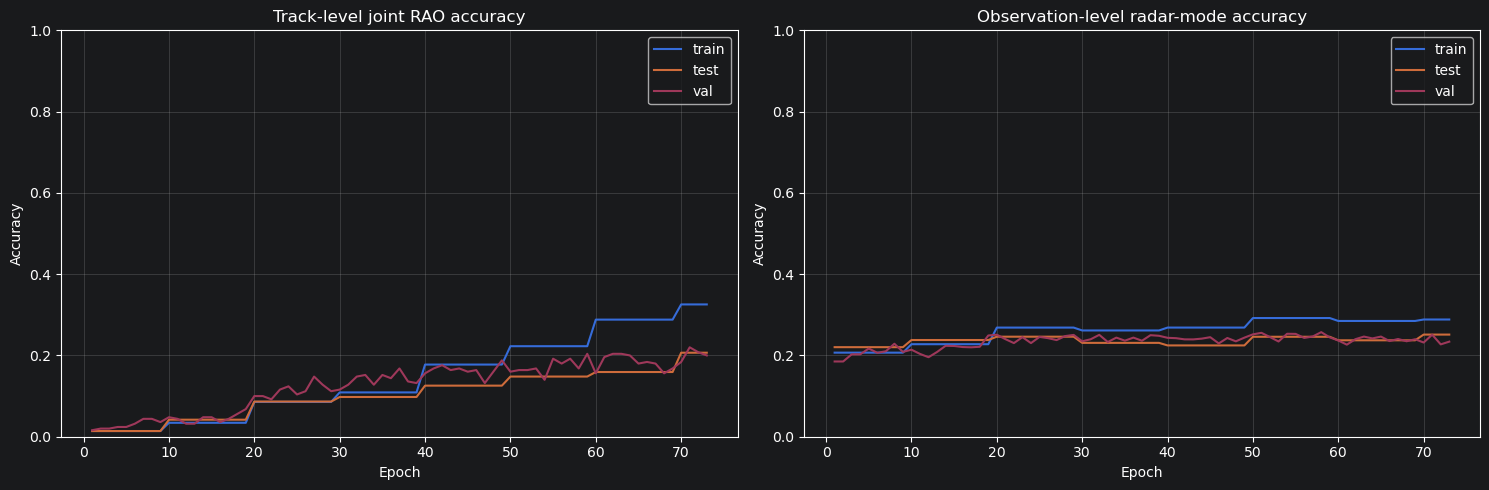

In [38]:
# Training curves for the two prediction levels.
epochs = [row["epoch"] for row in history]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for split in ("train", "test", "val"):
    axes[0].plot(epochs, [row[f"{split}_track_rao_acc"] for row in history], label=split)
    axes[1].plot(epochs, [row[f"{split}_radar_mode_acc"] for row in history], label=split)
axes[0].set(title="Track-level joint RAO accuracy", xlabel="Epoch", ylabel="Accuracy", ylim=(0, 1))
axes[1].set(title="Observation-level radar-mode accuracy", xlabel="Epoch", ylabel="Accuracy", ylim=(0, 1))
for axis in axes: axis.legend(); axis.grid(True, alpha=.3)
fig.tight_layout()
training_plot_path = ARTIFACT_DIR / "hierarchical_training_metrics.png"
fig.savefig(training_plot_path, dpi=150)
training_plot_path
